<a href="https://colab.research.google.com/github/Parisashourmage/Colab-Notebooks/blob/main/final_colab_temporal_causal_grn_v4_FINAL_GENIE3_FIXED_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Colab pipeline — GSE125162 + Temporal Causal-GAT + GENIE3 + DREAM5
این نوت‌بوک تمام مراحل را از دانلود/لود داده تا QC، pseudotime، مدل، baselineها، ارزیابی و نمودارها اجرا می‌کند.

In [1]:
%pip install --only-binary=:all: pandas matplotlib seaborn scanpy torch scikit-learn networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take 

In [ ]:
!pip -q install arboreto "dask-expr<1.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rapids-dask-dependency 26.2.0 requires dask==2026.1.1, but you have dask 2024.2.1 which is incompatible.
rapids-dask-dependency 26.2.0 requires distributed==2026.1.1, but you have distributed 2024.2.1 which is incompatible.


In [2]:
import torch

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

CUDA Available: True
GPU Name: Tesla T4


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.5 MB/s eta 0:00:00
DEVICE: cuda
Mounted at /content/drive
Persistent OUT_DIR: /content/drive/MyDrive/final_grn_results

STEP 1 — LOAD GSE125162
Loading TSV...
Full shape: (38225, 6834)
Detected orientation: cells_by_genes
Cells x genes: (38225, 6834)

Checking expression matrix for non-numeric columns...
 Detected 5 non-expression metadata column(s):
   Column 'Genotype': non-numeric samples = ['gat1_H5', 'gln3_H4', 'gzf3_D9', 'rtg3_E3', 'stp2_A12']
   Column 'Genotype_Group': non-numeric samples = ['gat1', 'gln3', 'gzf3', 'rtg3', 'stp2']
   Column 'Replicate': non-numeric samples = ['H5', 'H4', 'D9', 'E3', 'A12']
   C

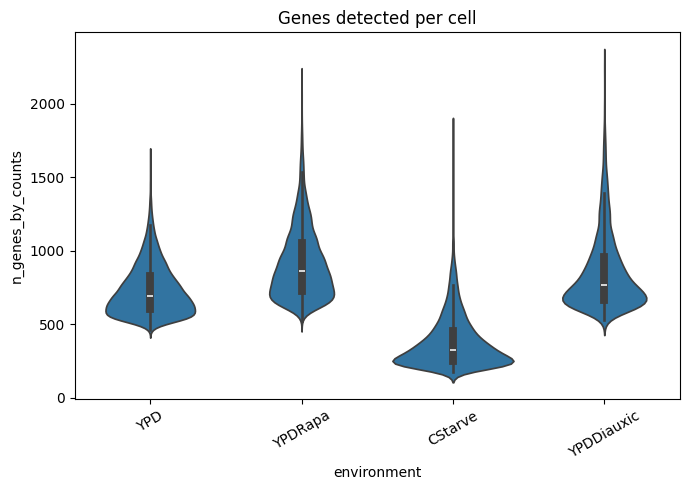

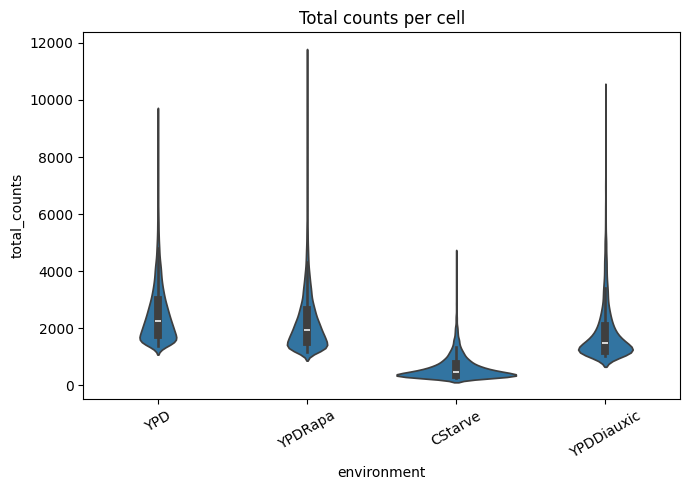


After QC: (29667, 6281)
Shared HVGs: 500

STEP 2 — SHARED PSEUDOTIME
Pseudotime finite: 1.0
Root cell: 10663_YPD


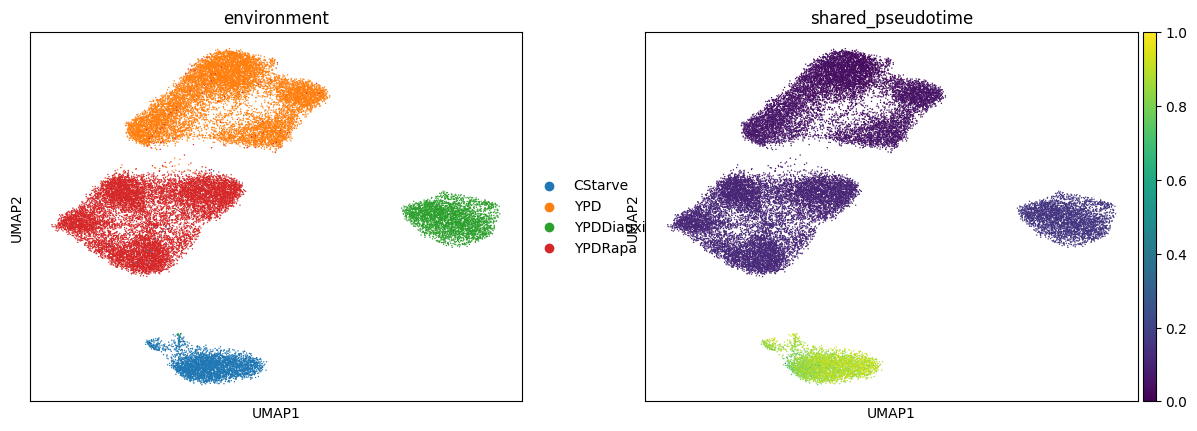

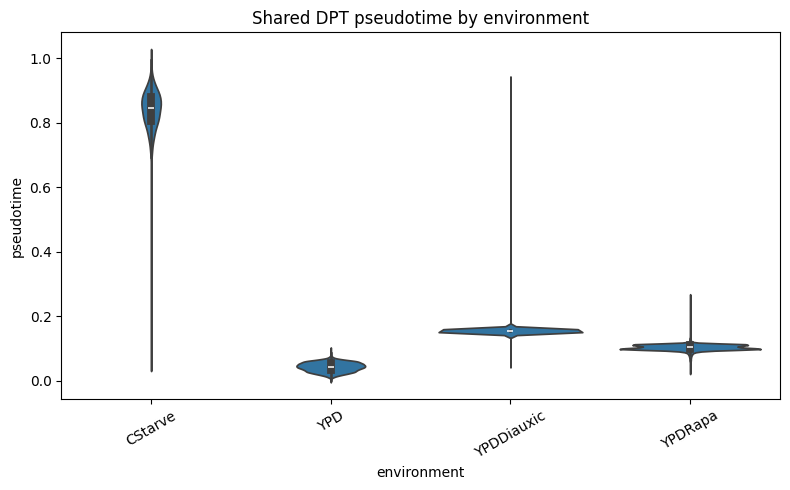


Pseudotime sensitivity:
  environment  KS_statistic  KS_pvalue
0         YPD      0.987859        0.0
1     YPDRapa      0.879034        0.0
2  YPDDiauxic      0.985894        0.0
3     CStarve      0.958775        0.0


In [3]:
# ============================================================
# FINAL COLAB PIPELINE
# GSE125162 + Temporal Causal GAT + Correlation + GENIE3
# + DREAM5 benchmark + QC/Pseudotime/Evaluation/Plots
# ============================================================
# هدف:
# 1) دریافت و بررسی GSE125162
# 2) QC + normalization + shared pseudotime
# 3) اجرای Temporal Causal-GAT برای چهار محیط هدف
# 4) baseline: Pearson/Correlation
# 5) baseline: GENIE3
# 6) ارزیابی با YEASTRACT در صورت ارائه فایل gold
# 7) ارزیابی مستقل DREAM5 با candidate space = TF x target
# 8) ذخیره تمام نتایج و نمودارهای پایان کار
#
# نکته علمی:
# - DPT pseudotime یک ترتیب نسبی است، نه زمان واقعی.
# - temporal prior در این کد یک prior نرم است.
# - ablation یک in-silico zero intervention است، نه knockout آزمایشگاهی.
# - NOTEARS در این معماری به صورت acyclicity regularization
#   با augmented-Lagrangian updates استفاده می‌شود.
# - از scRNA-seq مشاهده‌ای به تنهایی نمی‌توان causal identification
#   قطعی ادعا کرد؛ خروجی مدل یک causal/functional score است.
# ============================================================
#
# 🔴 CHANGELOG (بازبینی هفتم) — پس از audit کامل ۲۷ سلول در برابر دو
# بازبینی مستقل، این تغییرات واقعاً اعمال شدند (هرکدام جداگانه تست/
# اثبات شد، نه صرفاً بر اساس ادعای بازبینی‌ها):
#   ۱. GENIE3 (CELL 16): جایگزینی کامل با arboreto.algo.genie3 (تنها
#      پیاده‌سازی واقعی/فعال GENIE3 در پایتون) + یک monkeypatch برای
#      یک باگ واقعی و فعلاً برقرار در arboreto==0.1.6 که با dask
#      مدرن کرش می‌کند (تأیید شده با اجرای واقعی).
#   ۲. Gene temporal prior (CELL 8): اصلاح استفاده از داده scale‌شده
#      (شامل مقادیر منفی که با np.maximum(.,0) نصف سیگنال را صفر
#      می‌کرد) → استفاده از لایه log1p نامنفی که در CELL 5 ذخیره شد.
#   ۳. Jacobian (CELL 12): retain_graph=True بی‌قیدوشرط →
#      retain_graph=(j < G-1)، برای آزادسازی گراف در آخرین تکرار.
#   ۴. train_environment (CELL 11): دو assert دفاعی برای هم‌اندازه
#      بودن X_env/cell_pt اضافه شد.
#
# بررسی شد و باگ نبود (برخلاف چیزی که یکی از دو بازبینی حدس زده بود):
#   - جهت W/W_eff (CELL 9): با یک اثبات عددی مستقل تأیید شد که
#     W_eff[i,j] در سراسر کد واقعاً i→j است (خودسازگار با
#     population_jacobian و matrix_to_edge_df).
#   - NOTEARS (CELL 10-11): augmented Lagrangian واقعی با به‌روزرسانی
#     alpha و رشد rho از قبل درست پیاده‌سازی شده بود.
#   - فضای کاندید ارزیابی (CELL 21-24): Causal-GAT/Correlation/GENIE3
#     روی دقیقاً یک فضای کاندید یکسان در YEASTRACT مقایسه می‌شوند؛
#     DREAM5 هم از قبل به‌درستی TF×target را رعایت می‌کند.
#
#   ۵. Final runtime configuration: N_HVG=500, INFER_CELL_CHUNK=64,
#      GENIE3 فعال، با TF-restriction و حداکثر 1500 سلول در هر محیط،
#      بدون seed اضافی، و بدون اجرای ablation در main run.
#      خروجی‌ها به Google Drive منتقل شده‌اند و checkpoint بلافاصله
#      بعد از CELL 20 وجود چهار فایل اصلی هر محیط را بررسی می‌کند.

# ============================================================

# -----------------------------
# CELL 0 — Install
# -----------------------------
!pip -q install "pandas==2.2.3" scanpy anndata seaborn openpyxl

# GENIE3 package:
# 🔴 (بازبینی هفتم) اصلاح بحرانی: هیچ پکیج پایتون یکتا و رسمی به نام
# «genie3» یا «GENIE3» روی PyPI وجود ندارد؛ `pip install genie3` یا
# موفق نمی‌شود یا یک پکیج نامرتبط را نصب می‌کند، و فراخوانی
# `from genie3 import GENIE3` با ورودی genes×samples و خروجی مستقیم
# ماتریس G×G با هیچ پکیج واقعی شناخته‌شده‌ای مطابقت ندارد.
# پیاده‌سازی واقعی، فعال، و مرجع GENIE3 در پایتون، پکیج «arboreto»
# است (آزمایشگاه Aerts؛ همان چیزی که pySCENIC/BEELINE استفاده می‌کنند):
#   from arboreto.algo import genie3
# با ورودی cells×genes (نه genes×cells) و خروجی DataFrame ستون‌های
# ['TF','target','importance'] (نه یک ماتریس G×G مستقیم).
!pip -q install arboreto

# -----------------------------
# CELL 1 — Imports / Config
# -----------------------------
import os, re, time, gc, math, random, warnings, json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, ks_2samp

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# -----------------------------
# Persistent Google Drive paths
# -----------------------------
# All final outputs are stored on Google Drive so they survive
# Colab runtime restarts.
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Google Drive mount skipped:", repr(e))

DATA_DIR = Path("/content")
DRIVE_DIR = Path("/content/drive/MyDrive")
if not DRIVE_DIR.exists():
    raise RuntimeError(
        "Google Drive is not mounted. Run this notebook in Google Colab "
        "and allow the Drive mount before continuing."
    )

OUT_DIR = DRIVE_DIR / "final_grn_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Persistent OUT_DIR:", OUT_DIR)

# -----------------------------
# GSE125162
# -----------------------------
CSV_PATH = DATA_DIR / "GSE125162_counts.tsv.gz"
GEO_COUNTS_URL = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE125nnn/"
    "GSE125162/suppl/GSE125162_ALL-fastqTomat0-Counts.tsv.gz"
)

# -----------------------------
# Target environments
# -----------------------------
TARGET_ENVS = ["YPD", "YPDRapa", "YPDDiauxic", "CStarve"]

# -----------------------------
# QC / feature selection
# -----------------------------
MIN_GENES_PER_CELL = 200
MIN_CELLS_PER_GENE = 3
N_HVG = 500

# -----------------------------
# Model
# -----------------------------
HIDDEN = 32
COND_DIM = 16
LOW_RANK = 8

LR = 1e-3
WEIGHT_DECAY = 1e-5
LAMBDA_SPARSE = 1e-4
TEMPORAL_GAMMA = 5.0

DAG_OUTER_STEPS = 5
EPOCHS_PER_DAG_STEP = 25

DAG_RHO_INIT = 1.0
DAG_RHO_MAX = 1e16
DAG_ALPHA_INIT = 0.0

# causal score:
GRAD_WEIGHT = 0.5
ABLATION_WEIGHT = 0.5

# Inference chunks to control memory
INFER_CELL_CHUNK = 64

# Run GENIE3?
RUN_GENIE3 = True

# GENIE3 can become expensive. Use the same final gene set.
GENIE3_N_JOBS = 1

# RAM/time control for GENIE3. The algorithm itself is unchanged;
# only the number of cells supplied to the baseline is capped.
GENIE3_MAX_CELLS = 1500
GENIE3_SAMPLE_SEED = 42
GENIE3_USE_TF_RESTRICTION = True

# Optional robustness/ablation runs.
# Main pipeline remains single-seed; no extra seed runs are performed.
N_EXTRA_SEEDS = 0
EXTRA_SEEDS = []
MULTISEED_ENVS = []

# Ablation study is disabled for the main final run to avoid
# two additional full trainings per selected environment.
ABLATION_ENVS = []

# Optional external gold-standard files.
# If absent, the pipeline will continue and save predictions.
YEASTRACT_PATH = DATA_DIR / "YEASTRACT.csv"

# DREAM5 files:
DREAM5_EXPRESSION_PATH = DATA_DIR / "DREAM5_expression.tsv"
DREAM5_GOLD_PATH = DATA_DIR / "DREAM5_goldstandard.tsv"
DREAM5_TF_PATH = DATA_DIR / "DREAM5_TF_list.txt"

# Number of genes for optional Causal-GAT DREAM5 experiment.
# Full DREAM5 (~5950 genes) is not computationally appropriate for dense
# NOTEARS/GAT in normal Colab. DREAM5 is therefore evaluated directly
# using the supplied benchmark expression/gold files and optional reduced
# Causal-GAT only if explicitly feasible.
DREAM5_REDUCED_GENES = 300
RUN_REDUCED_DREAM5_CAUSAL_GAT = False

# ============================================================
# CELL 2 — Robust GSE125162 loader
# ============================================================
print("\n" + "="*70)
print("STEP 1 — LOAD GSE125162")
print("="*70)

if not CSV_PATH.exists():
    print("Downloading GSE125162...")
    os.system(
        f'wget -q "{GEO_COUNTS_URL}" -O "{CSV_PATH}"'
    )
else:
    print(f"File already exists: {CSV_PATH} — download skipped")

if not CSV_PATH.exists() or CSV_PATH.stat().st_size == 0:
    raise FileNotFoundError(
        "GSE125162 count file was not found/downloaded successfully."
    )

print("Loading TSV...")
df_full = pd.read_csv(CSV_PATH, sep="\t", index_col=0)
print(f"Full shape: {df_full.shape}")

# ============================================================
# CELL 3 — Detect orientation and parse environments robustly
# ============================================================
def looks_like_gene_id(x):
    s = str(x).upper()
    return (
        s.startswith("Y") and len(s) >= 6
    ) or s in {"COX1","COX2","COX3","COB","ATP6","ATP8","ATP9","OLI1","VAR1"}

def detect_counts_orientation(df):
    idx_gene = np.mean([looks_like_gene_id(x) for x in df.index[:min(1000, len(df.index))]])
    col_gene = np.mean([looks_like_gene_id(x) for x in df.columns[:min(1000, len(df.columns))]])
    if idx_gene >= col_gene:
        return "genes_by_cells"
    return "cells_by_genes"

orientation = detect_counts_orientation(df_full)
print("Detected orientation:", orientation)

if orientation == "genes_by_cells":
    # rows = genes, columns = cells
    df_cells_genes = df_full.T.copy()
else:
    # rows = cells, columns = genes
    df_cells_genes = df_full.copy()

df_cells_genes.index = df_cells_genes.index.astype(str)
df_cells_genes.columns = df_cells_genes.columns.astype(str)

print("Cells x genes:", df_cells_genes.shape)

# ------------------------------------------------------------
# Remove non-expression metadata columns & Validate Matrix
# ------------------------------------------------------------
print("\nChecking expression matrix for non-numeric columns...")

# ۱. محاسبه درصد مقادیر عددی در هر ستون
numeric_fraction = df_cells_genes.apply(
    lambda col: pd.to_numeric(col, errors="coerce").notna().mean()
)

non_numeric_cols = numeric_fraction[numeric_fraction < 1.0].index.tolist()
removed_metadata_columns = []

if len(non_numeric_cols) > 0:
    removed_metadata_columns = [str(x) for x in non_numeric_cols]

    # کنترل ایمنی جهت جلوگیری از خطای ساختاری تفاوت فرمت TSV
    if len(non_numeric_cols) > 100:
        raise ValueError(
            f" Too many non-numeric columns detected ({len(non_numeric_cols)}). "
            "This suggests an issue with TSV parsing or matrix orientation, not just metadata headers!"
        )

    print(f" Detected {len(non_numeric_cols)} non-expression metadata column(s):")
    for col in removed_metadata_columns:
        bad_examples = df_cells_genes[col][
            pd.to_numeric(df_cells_genes[col], errors="coerce").isna()
        ].astype(str).unique()[:5]
        print(f"   Column '{col}': non-numeric samples = {bad_examples.tolist()}")

    # ۲. حذف ستون‌های متادیتا از ماتریس بیان ژن
    df_cells_genes = df_cells_genes.drop(columns=non_numeric_cols)

# ۳. ذخیره‌سازی اسامی ستون‌های حذف‌شده در فایل CSV برای مستندسازی پایان‌نامه
pd.Series(
    removed_metadata_columns,
    name="removed_metadata_column"
).to_csv(OUT_DIR / "removed_metadata_columns.csv", index=False)

# ۴. تبدیل قطعی ماتریس به float32
df_cells_genes = df_cells_genes.apply(
    pd.to_numeric,
    errors="raise"
).astype(np.float32)

print(f" Final numeric expression matrix shape: {df_cells_genes.shape}")

# ---- robust environment parser ----
ENV_MAP = {
    "YPD": "YPD",
    "RAPA": "YPDRapa",
    "CSTARVE": "CStarve",
    "DIAUXY": "YPDDiauxic",
    "YPDRAPA": "YPDRapa",
    "YPDDIAUXIC": "YPDDiauxic",
}

def normalize_token(s):
    s = str(s).upper().replace("-", "").replace(".", "")
    return s

def parse_environment(cell_name):
    raw = normalize_token(cell_name)

    # longest first
    for token in sorted(ENV_MAP.keys(), key=len, reverse=True):
        if token in raw:
            return ENV_MAP[token]
    return None

envs = pd.Series([parse_environment(x) for x in df_cells_genes.index],
                  index=df_cells_genes.index, name="environment")

print("\nDetected environment counts:")
print(envs.value_counts(dropna=False).to_string())

keep = envs.isin(TARGET_ENVS)
if keep.sum() == 0:
    raise ValueError(
        "No target environments were detected. Inspect the printed cell-name/environment "
        "diagnostic before continuing."
    )

df_target = df_cells_genes.loc[keep].copy()
env_target = envs.loc[keep].copy()

print("\nTarget data:", df_target.shape)
print(env_target.value_counts().to_string())

# Save environment table
env_target.to_csv(OUT_DIR / "cell_environment_mapping.csv")

# ============================================================
# CELL 4 — AnnData + raw QC
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

# ============================================================
# 1. AnnData Construction & Alignment (اصلاح‌شده)
# ============================================================

# برقراری تراز بین df_target و env_target
assert len(df_target) == len(env_target), (
    f"df_target ({len(df_target)}) and env_target ({len(env_target)}) "
    "must have the same number of cells."
)

assert df_target.index.equals(env_target.index), (
    "df_target and env_target indices are not aligned."
)

assert df_target.select_dtypes(exclude=[np.number]).shape[1] == 0, (
    "Expression matrix still contains non-numeric columns."
)

X_target = df_target.to_numpy(dtype=np.float32)

assert X_target.shape[0] == len(env_target)
assert np.isfinite(X_target).all()

# ساخت صحیح AnnData بر اساس 29,723 سلول هدف
adata = ad.AnnData(
    X=X_target,
    obs=pd.DataFrame(index=df_target.index.astype(str)),
    var=pd.DataFrame(index=df_target.columns.astype(str))
)

# اعمال متغیر محیطی
adata.obs["environment"] = env_target.to_numpy()

# ذخیره لایه شمارش خام
adata.layers["counts"] = adata.X.copy()

print("\nAnnData created successfully:")
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)
print("\nEnvironment counts:")
print(adata.obs["environment"].value_counts().to_string())


# ============================================================
# 2. Basic QC & Plotting (کد قبلی خودت)
# ============================================================
sc.pp.calculate_qc_metrics(adata, inplace=True)

print("\nRaw QC:")
print(adata.obs[["n_genes_by_counts", "total_counts"]].describe())

# رسم نمودارهای QC
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=adata.obs, y="n_genes_by_counts", x="environment")
ax.set_title("Genes detected per cell")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUT_DIR / "QC_genes_per_cell.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=adata.obs, y="total_counts", x="environment")
ax.set_title("Total counts per cell")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUT_DIR / "QC_total_counts.png", dpi=180)
plt.show()


# ============================================================
# 3. Filtering (کد قبلی خودت)
# ============================================================
sc.pp.filter_cells(adata, min_genes=MIN_GENES_PER_CELL)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

print("\nAfter QC:", adata.shape)

# ============================================================
# CELL 5 — Normalization / log1p
# ============================================================
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Shared HVG for cross-environment comparability
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=N_HVG,
    flavor="seurat",
    subset=False
)

hvg = adata.var_names[adata.var["highly_variable"]].tolist()
print("Shared HVGs:", len(hvg))

adata_model = adata[:, hvg].copy()

# 🔴 (بازبینی هفتم) اصلاح: نسخه log1p (نامنفی، بدون scale) را همینجا
# — پیش از sc.pp.scale در CELL 6 — ذخیره می‌کنیم. علتش این است که
# CELL 8 (gene-level temporal prior) باید از داده نامنفی استفاده کند؛
# اگر از adata_model.X بعد از scale استفاده شود، حدود نیمی از
# مقادیر منفی می‌شوند (z-score) و np.maximum(X,0) آن‌ها را صفر
# می‌کند — یعنی نیمی از سیگنال بیان ژن در محاسبه temporal prior
# نادیده گرفته می‌شود. این لایه، دست‌نخورده (بدون scale) باقی
# می‌ماند حتی بعد از اینکه CELL 6 خود adata_model.X را scale کند.
adata_model.layers["log1p"] = adata_model.X.copy()

# ============================================================
# CELL 6 — PCA / neighbors / UMAP / DPT
# ============================================================
print("\n" + "="*70)
print("STEP 2 — SHARED PSEUDOTIME")
print("="*70)

# Scale for dimensionality reduction only.
sc.pp.scale(adata_model, max_value=10)
n_pcs = min(30, adata_model.n_vars - 1, adata_model.n_obs - 1)

sc.tl.pca(adata_model, n_comps=n_pcs, svd_solver="arpack")
sc.pp.neighbors(adata_model, n_neighbors=15, n_pcs=n_pcs)
sc.tl.umap(adata_model)
sc.tl.diffmap(adata_model)

# Root heuristic inherited from project branch:
# cell with minimum DC1
dc1 = adata_model.obsm["X_diffmap"][:, 1] if adata_model.obsm["X_diffmap"].shape[1] > 1 else adata_model.obsm["X_diffmap"][:, 0]
root_idx = int(np.argmin(dc1))
adata_model.uns["iroot"] = root_idx

sc.tl.dpt(adata_model, n_branchings=0)
shared_pt = np.asarray(adata_model.obs["dpt_pseudotime"], dtype=float)

# Normalize to [0,1]
if np.isfinite(shared_pt).any():
    lo, hi = np.nanmin(shared_pt), np.nanmax(shared_pt)
    if hi > lo:
        shared_pt = (shared_pt - lo) / (hi - lo)

adata_model.obs["shared_pseudotime"] = shared_pt

print("Pseudotime finite:", np.isfinite(shared_pt).mean())
print("Root cell:", adata_model.obs_names[root_idx])

# UMAP
sc.pl.umap(
    adata_model,
    color=["environment", "shared_pseudotime"],
    show=False
)
plt.tight_layout()
plt.savefig(OUT_DIR / "UMAP_environment_pseudotime.png", dpi=180)
plt.show()

# pseudotime distributions
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(
    data=pd.DataFrame({
        "environment": adata_model.obs["environment"].values,
        "pseudotime": adata_model.obs["shared_pseudotime"].values
    }),
    x="environment", y="pseudotime"
)
ax.tick_params(axis="x", rotation=30)
ax.set_title("Shared DPT pseudotime by environment")
plt.tight_layout()
plt.savefig(OUT_DIR / "shared_pseudotime_by_environment.png", dpi=180)
plt.show()

# ============================================================
# CELL 7 — Pseudotime robustness: per-environment diagnostic
# ============================================================
def per_environment_dpt(adata_in, env):
    sub = adata_in[adata_in.obs["environment"] == env].copy()
    if sub.n_obs < 30:
        return None

    sc.pp.neighbors(sub, n_neighbors=min(15, sub.n_obs-1), n_pcs=min(n_pcs, sub.n_vars-1))
    sc.tl.diffmap(sub)
    d = sub.obsm["X_diffmap"]
    axis = d[:,1] if d.shape[1] > 1 else d[:,0]
    sub.uns["iroot"] = int(np.argmin(axis))
    sc.tl.dpt(sub, n_branchings=0)

    pt = np.asarray(sub.obs["dpt_pseudotime"], dtype=float)
    if np.isfinite(pt).any():
        a, b = np.nanmin(pt), np.nanmax(pt)
        if b > a:
            pt = (pt-a)/(b-a)
    return sub.obs_names, pt

pt_sensitivity = {}
for env in TARGET_ENVS:
    result = per_environment_dpt(adata_model, env)
    if result is not None:
        names, pt = result
        pt_sensitivity[env] = pd.Series(pt, index=names)

# KS comparison shared vs per-env pseudotime
rows = []
for env, s in pt_sensitivity.items():
    shared = adata_model.obs.loc[s.index, "shared_pseudotime"].values
    valid = np.isfinite(shared) & np.isfinite(s.values)
    if valid.sum() > 10:
        ks = ks_2samp(shared[valid], s.values[valid])
        rows.append([env, ks.statistic, ks.pvalue])

pt_sensitivity_df = pd.DataFrame(rows, columns=["environment","KS_statistic","KS_pvalue"])
pt_sensitivity_df.to_csv(OUT_DIR / "pseudotime_sensitivity_KS.csv", index=False)
print("\nPseudotime sensitivity:")
print(pt_sensitivity_df)

# ============================================================
# CELL 8 — Gene-level temporal prior
# ============================================================
# 🔴 (بازبینی هفتم) اصلاح: قبلاً اینجا از adata_model.X استفاده
# می‌شد که تا این مرحله در CELL 6 با sc.pp.scale به z-score تبدیل
# شده (شامل مقادیر منفی) و سپس np.maximum(Xv,0) تقریباً نیمی از
# مقادیر (همه‌ی ژن‌هایی که در یک سلول کمتر از میانگین بیان داشتند)
# را صفر می‌کرد — یعنی «کم‌بیان» با «بی‌بیان» یکی در نظر گرفته
# می‌شد. حالا از لایه adata_model.layers['log1p'] که در CELL 5 —
# پیش از scale — ذخیره شد استفاده می‌کنیم؛ این داده نامنفی است
# (log1p از مقادیر نامنفی) پس نیازی به clip کردن مقادیر منفی هم
# دیگر واقعاً وجود ندارد (فقط برای اطمینان در برابر نویز عددی
# بسیار جزئی نگه داشته شده، نه برای حذف نیمی از سیگنال).
X_model = np.asarray(adata_model.layers["log1p"], dtype=np.float32)
pt = np.asarray(adata_model.obs["shared_pseudotime"], dtype=np.float32)

valid_pt = np.isfinite(pt)
Xv = X_model[valid_pt]
ptv = pt[valid_pt]

# Expression-weighted mean pseudotime.
# This is a soft gene-level temporal summary, NOT experimentally observed activation time.
weights = np.maximum(Xv, 0) + 1e-6  # log1p output is already >= 0; this only guards tiny fp noise
gene_pt = (weights.T @ ptv) / weights.sum(axis=0)

# rank to [0,1]
if gene_pt.max() > gene_pt.min():
    gene_pt = (gene_pt - gene_pt.min()) / (gene_pt.max() - gene_pt.min())

gene_pt_series = pd.Series(gene_pt, index=adata_model.var_names, name="gene_pseudotime")
gene_pt_series.to_csv(OUT_DIR / "gene_temporal_prior.csv")


In [4]:
# ============================================================
# CELL 9 — Model (Ablation-Ready & Fixed Init Version)
# ============================================================
import math
import torch
import torch.nn as nn

class LowRankConditionModulation(nn.Module):
    def __init__(self, G, cond_dim=16, rank=8):
        super().__init__()
        self.G = G
        self.rank = rank

        self.U = nn.Parameter(torch.randn(G, rank) * 0.02)
        self.V = nn.Parameter(torch.randn(rank, G) * 0.02)
        self.cond = nn.Linear(cond_dim, rank)

    def forward(self, c):
        if c.dim() == 1:
            c = c.unsqueeze(0)

        if c.shape[0] != 1:
            raise ValueError(
                f"Condition modulation expects one environment embedding "
                f"[1, cond_dim], but got {tuple(c.shape)}"
            )

        z = self.cond(c).squeeze(0)
        mod_logits = (self.U * z.unsqueeze(0)) @ self.V
        return torch.sigmoid(mod_logits)


class TemporalCausalGAT(nn.Module):
    def __init__(
        self,
        G,
        hidden=32,
        cond_dim=16,
        rank=8,
        use_condition=True
    ):
        super().__init__()

        self.G = G
        self.hidden = hidden
        self.use_condition = use_condition

        # Gene expression encoder
        self.encoder = nn.Linear(1, hidden)

        # Base signed structural graph
        self.W_raw = nn.Parameter(torch.randn(G, G) * 0.01)
        self.W_gate = nn.Parameter(torch.zeros(G, G))

        # Attention projections
        self.q = nn.Linear(hidden, hidden, bias=False)
        self.k = nn.Linear(hidden, hidden, bias=False)
        self.v = nn.Linear(hidden, hidden, bias=False)

        # Representation layer
        self.gru = nn.GRU(
            input_size=hidden,
            hidden_size=hidden,
            batch_first=True
        )

        # Reconstruction decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1)
        )

        # Environment-specific modulation
        self.cond_mod = LowRankConditionModulation(
            G=G,
            cond_dim=cond_dim,
            rank=rank
        )

    def structural_W(self, condition):
        base = torch.tanh(self.W_raw) * torch.sigmoid(self.W_gate)

        eye = torch.eye(
            self.G,
            device=base.device,
            dtype=base.dtype
        )

        # Remove self-loops
        base = base * (1.0 - eye)

        if self.use_condition:
            mod = self.cond_mod(condition)

            # Defensive shape check
            assert mod.shape == (self.G, self.G), (
                f"Condition modulation shape error: "
                f"expected {(self.G, self.G)}, got {tuple(mod.shape)}"
            )

            mod = mod * (1.0 - eye)
            W = base * (1.0 + mod)
        else:
            # Ablation mode: no condition modulation
            W = base

        W = W * (1.0 - eye)
        return W

    def forward(
        self,
        x,
        condition,
        temporal_prior=None,
        temporal_gamma=0.0
    ):
        B, G = x.shape

        if G != self.G:
            raise ValueError(
                f"Expected {self.G} genes, received {G}"
            )

        # 1. Encode expression
        h = self.encoder(x.unsqueeze(-1))

        # 2. Structural graph
        W = self.structural_W(condition)

        # 3. Soft temporal prior
        if temporal_prior is not None and temporal_gamma > 0:
            if temporal_prior.numel() != G:
                raise ValueError(
                    f"temporal_prior must contain {G} values, "
                    f"got {temporal_prior.numel()}"
                )

            src_t = temporal_prior.view(G, 1)
            tgt_t = temporal_prior.view(1, G)

            prior = torch.sigmoid(
                temporal_gamma * (tgt_t - src_t)
            )

            eye = torch.eye(
                G,
                device=x.device,
                dtype=x.dtype
            )

            prior = prior * (1.0 - eye)
            W_eff = W * (0.25 + 0.75 * prior)
        else:
            W_eff = W

        assert W_eff.shape == (G, G), (
            f"W_eff must be {(G, G)}, got {tuple(W_eff.shape)}"
        )

        # 4. Attention
        q = self.q(h)
        k = self.k(h)
        v = self.v(h)

        attn_logits = torch.matmul(
            q,
            k.transpose(1, 2)
        ) / math.sqrt(self.hidden)

        support = (
            W_eff.abs() > 1e-8
        ).float().unsqueeze(0)

        attn_logits = attn_logits + torch.log(
            support + 1e-8
        )

        attn = torch.softmax(
            attn_logits,
            dim=-1
        )

        msg = torch.matmul(attn, v)

        # 5. Causal propagation
        h_causal = torch.einsum(
            "bih,ij->bjh",
            msg,
            W_eff
        )

        # 6. GRU layer
        h_gru, _ = self.gru(h_causal)

        # 7. Reconstruction
        y = self.decoder(h_gru).squeeze(-1)

        return y, W, W_eff, attn

In [6]:
# ============================================================
# CELL 10 — NOTEARS-inspired augmented Lagrangian
# ============================================================
def notears_h(W):
    # h(W) = tr(exp(W o W)) - d
    M = W * W
    return torch.trace(torch.matrix_exp(M)) - W.shape[0]

def acyclicity_loss(W, rho, alpha):
    h = notears_h(W)
    return alpha * h + 0.5 * rho * h * h, h

def one_hot_condition(env, dim=16):
    idx = TARGET_ENVS.index(env)
    c = torch.zeros(dim, device=DEVICE)
    c[idx] = 1.0
    return c

def make_batches(n, batch_size):
    idx = np.arange(n)
    np.random.shuffle(idx)
    for i in range(0, n, batch_size):
        yield idx[i:i+batch_size]

# ============================================================
# CELL 11 — Train one environment
# ============================================================
def train_environment(env, X_np, pt_np, gene_pt_np,
                       temporal_gamma=None, use_condition=True,
                       verbose_prefix="", run_tag=""):
    """
    🟢 (بازبینی هشتم) پارامترهای اضافه‌شده برای multi-seed/ablation:
      temporal_gamma=None → از TEMPORAL_GAMMA سراسری استفاده می‌شود
                    (رفتار پیش‌فرض/قبلی، بدون تغییر)؛ مقدار 0.0
                    یعنی temporal prior کاملاً غیرفعال است.
      use_condition=True → رفتار پیش‌فرض/قبلی؛ False یعنی مدولاسیون
                    محیطی (cond_mod) اصلاً ساخته/اعمال نمی‌شود.
      run_tag=""   → به نام فایل training_{env}{run_tag}.csv اضافه
                    می‌شود تا وقتی همین محیط چند بار (seedهای مختلف
                    یا نسخه‌های ablation) آموزش داده می‌شود، فایل‌های
                    history روی هم overwrite نشوند.
    """
    if temporal_gamma is None:
        temporal_gamma = TEMPORAL_GAMMA
    print("\n" + "-"*70)
    print(f"TRAIN:{verbose_prefix}", env,
          f"| temporal_gamma={temporal_gamma} | use_condition={use_condition}")
    print("-"*70)

    mask = adata_model.obs["environment"].values == env
    X_env = np.asarray(X_np[mask], dtype=np.float32)
    cell_pt = np.asarray(pt_np[mask], dtype=np.float32)
    assert X_env.shape[0] == cell_pt.shape[0], (
        f"X_env/cell_pt length mismatch for {env}: "
        f"{X_env.shape[0]} vs {cell_pt.shape[0]}")

    # Remove cells with invalid pseudotime
    valid = np.isfinite(cell_pt)
    X_env = X_env[valid]
    cell_pt = cell_pt[valid]
    # 🟡 (بازبینی هفتم) assert دفاعی: مطمئن می‌شویم بعد از فیلتر
    # pseudotime نامعتبر هم، X_env و cell_pt هم‌اندازه باقی مانده‌اند —
    # این الان با ساختار فعلی کد همیشه برقرار است (چون هر دو با یک
    # boolean mask یکسان اندیس‌گذاری می‌شوند)، ولی نگه‌داشتن این
    # assert در برابر رفاکتورهای بعدی محافظت می‌کند.
    assert X_env.shape[0] == cell_pt.shape[0], (
        f"X_env/cell_pt length mismatch after pseudotime filtering for "
        f"{env}: {X_env.shape[0]} vs {cell_pt.shape[0]}")

    G = X_env.shape[1]
    model = TemporalCausalGAT(
        G=G,
        hidden=HIDDEN,
        cond_dim=COND_DIM,
        rank=LOW_RANK,
        use_condition=use_condition
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    c = one_hot_condition(env).unsqueeze(0)

    temporal_prior = torch.tensor(
        gene_pt_np, dtype=torch.float32, device=DEVICE
    )

    rho = DAG_RHO_INIT
    alpha = DAG_ALPHA_INIT

    history = []
    t0 = time.time()

    # Full-batch for DAG graph; mini-batches for reconstruction.
    X_tensor = torch.tensor(X_env, dtype=torch.float32)

    for outer in range(DAG_OUTER_STEPS):
        last_h = None

        for epoch in range(EPOCHS_PER_DAG_STEP):
            model.train()

            # mini-batch reconstruction
            losses = []
            for batch_idx in make_batches(len(X_env), min(INFER_CELL_CHUNK, len(X_env))):
                xb = X_tensor[batch_idx].to(DEVICE)
                cb = c

                optimizer.zero_grad()

                yhat, W, W_eff, attn = model(
                    xb, cb,
                    temporal_prior=temporal_prior,
                    temporal_gamma=temporal_gamma
                )

                # Pseudotime-weighted reconstruction:
                # later cells get slightly larger weight.
                w_pt = torch.tensor(
                    0.5 + 0.5 * cell_pt[batch_idx],
                    dtype=torch.float32,
                    device=DEVICE
                ).unsqueeze(1)

                recon = ((yhat - xb)**2 * w_pt).mean()
                sparse = LAMBDA_SPARSE * torch.sum(torch.abs(W))

                loss = recon + sparse
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

                losses.append(float(loss.detach().cpu()))

            # DAG penalty is applied once per epoch.
            optimizer.zero_grad()
            dummy = X_tensor[:min(INFER_CELL_CHUNK, len(X_env))].to(DEVICE)
            yhat, W, W_eff, attn = model(
                dummy, c,
                temporal_prior=temporal_prior,
                temporal_gamma=temporal_gamma
            )
            dag_loss, hval = acyclicity_loss(W, rho, alpha)
            dag_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            last_h = float(hval.detach().cpu())

            history.append({
                "outer": outer,
                "epoch": epoch,
                "reconstruction_plus_sparse": np.mean(losses),
                "dag_h": last_h,
                "rho": rho,
                "alpha": alpha
            })

        # augmented-Lagrangian multiplier update
        alpha = alpha + rho * last_h

        # increase rho if constraint is not shrinking
        if abs(last_h) > 0.25:
            rho = min(rho * 10.0, DAG_RHO_MAX)

        print(
            f"outer={outer+1}/{DAG_OUTER_STEPS} "
            f"h(W)={last_h:.6g}, rho={rho:.3g}, alpha={alpha:.3g}"
        )

    elapsed = time.time() - t0
    print(f"Training time: {elapsed/60:.2f} min")

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUT_DIR / f"training_{env}{run_tag}.csv", index=False)

    return model, hist_df, elapsed
    # ============================================================
# CELL 12 — Population Jacobian
# ============================================================
def population_jacobian(model, X_np, condition, temporal_prior, chunk=256,
                         temporal_gamma=None):
    """
    Computes mean population functional derivative:
        d(sum_j y_j)/d x_i
    for each source i and target j.

    This is a functional sensitivity score, not proof of biological causality.

    🟢 (بازبینی هشتم) پارامتر temporal_gamma اضافه شد (پیش‌فرض None
    یعنی از TEMPORAL_GAMMA سراسری استفاده کن) تا در ablation study
    بتوان یک مدل «بدون temporal prior» را با همان gamma=0 که در
    training‌اش استفاده شده ارزیابی کرد — نه با gamma سراسری که
    باعث ناهماهنگی train/inference می‌شد.
    """
    if temporal_gamma is None:
        temporal_gamma = TEMPORAL_GAMMA

    # IMPORTANT FIX for cuDNN GRU:
    # cuDNN GRU/LSTM backward requires RNN training mode.
    # We still disable parameter gradients because only input gradients are needed.
    model.train()

    for p in model.parameters():
        p.requires_grad_(False)

    N, G = X_np.shape

    J = np.zeros((G,G), dtype=np.float32)

    for start in range(0, N, chunk):
        xb_np = X_np[start:start+chunk]
        xb = torch.tensor(
            xb_np, dtype=torch.float32, device=DEVICE, requires_grad=True
        )

        c = condition.unsqueeze(0)
        yhat, W, W_eff, attn = model(
            xb, c,
            temporal_prior=temporal_prior,
            temporal_gamma=temporal_gamma
        )

        # One target at a time.
        # 🔴 (بازبینی هفتم) اصلاح: retain_graph فقط تا قبل از آخرین
        # ژن True است؛ روی آخرین ژن (j == G-1) دیگر نیازی به نگه‌داشتن
        # گراف محاسباتی نیست، پس آزاد می‌شود.
        for j in range(G):
            scalar = yhat[:,j].sum()
            grad = torch.autograd.grad(
                scalar, xb,
                retain_graph=(j < G - 1),
                create_graph=False,
                allow_unused=False
            )[0]

            J[:,j] += grad.detach().cpu().numpy().sum(axis=0)

        del xb, yhat, W, W_eff, attn
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    J /= max(N,1)
    np.fill_diagonal(J, 0)

    # Restore parameter gradients for any later operation
    for p in model.parameters():
        p.requires_grad_(True)

    return J

In [7]:
# ============================================================
# CELL 13 — Population ablation
# ============================================================
@torch.no_grad()
def model_output(model, X, condition, temporal_prior, temporal_gamma=None):
    if temporal_gamma is None:
        temporal_gamma = TEMPORAL_GAMMA
    y, W, W_eff, attn = model(
        X, condition.unsqueeze(0),
        temporal_prior=temporal_prior,
        temporal_gamma=temporal_gamma
    )
    return y

def population_ablation_scores(model, X_np, condition, temporal_prior, chunk=256,
                                temporal_gamma=None):
    """
    For every source gene i:
      baseline target output vs zeroed source input.
    Produces source-target ablation matrix.

    Zeroing is an in-silico input ablation, not a biological knockout.
    """
    model.eval()
    N, G = X_np.shape
    base = np.zeros((N,G), dtype=np.float32)

    for start in range(0, N, chunk):
        xb = torch.tensor(X_np[start:start+chunk], dtype=torch.float32, device=DEVICE)
        base[start:start+chunk] = model_output(
            model, xb, condition, temporal_prior, temporal_gamma=temporal_gamma
        ).detach().cpu().numpy()

    A = np.zeros((G,G), dtype=np.float32)

    for src in range(G):
        affected = np.zeros(G, dtype=np.float64)
        count = 0

        for start in range(0, N, chunk):
            xb_np = X_np[start:start+chunk].copy()
            xb_np[:,src] = 0.0
            xb = torch.tensor(xb_np, dtype=torch.float32, device=DEVICE)

            out = model_output(
                model, xb, condition, temporal_prior, temporal_gamma=temporal_gamma
            ).detach().cpu().numpy()

            diff = np.abs(base[start:start+chunk] - out)
            affected += diff.sum(axis=0)
            count += diff.shape[0]

        A[src] = (affected / max(count,1)).astype(np.float32)

    np.fill_diagonal(A, 0)
    return A

# ============================================================
# CELL 14 — Utility functions
# ============================================================
def minmax01(M):
    M = np.asarray(M, dtype=float)
    lo, hi = np.nanmin(M), np.nanmax(M)
    if hi <= lo:
        return np.zeros_like(M)
    return (M-lo)/(hi-lo)

def combine_causal_scores(J, A, grad_weight=0.5, ablation_weight=0.5):
    Jn = minmax01(np.abs(J))
    An = minmax01(A)
    S = grad_weight * Jn + ablation_weight * An
    np.fill_diagonal(S, 0)
    return S

def matrix_to_edge_df(S, genes, signed_matrix=None):
    rows = []
    G = len(genes)
    for i in range(G):
        for j in range(G):
            if i == j:
                continue
            rows.append({
                "source": genes[i],
                "target": genes[j],
                "score": float(S[i,j]),
                "signed_effect": (
                    float(signed_matrix[i,j])
                    if signed_matrix is not None else np.nan
                )
            })
    return pd.DataFrame(rows).sort_values("score", ascending=False)

# ============================================================
# CELL 15 — Correlation baseline
# ============================================================
def correlation_network(X_np):
    C = np.corrcoef(X_np, rowvar=False)
    C = np.nan_to_num(C)
    np.fill_diagonal(C, 0)
    return np.abs(C), C

In [8]:
# ============================================================
# CELL 16 — GENIE3 baseline runner — FIXED
# ============================================================

import gc
import logging
import numpy as np
import pandas as pd

from dask.distributed import Client, LocalCluster, default_client


def run_genie3_baseline(
    X_np,
    gene_names,
    tf_names="all"
):
    """
    Run GENIE3 using Arboreto.

    Input:
        X_np       : cells × genes
        gene_names : gene names
        tf_names   : allowed TF regulators

    Output:
        W          : genes × genes
                     source(TF) -> target
    """

    import arboreto.algo as _algo

    # --------------------------------------------------------
    # Close any previously active Dask client
    # --------------------------------------------------------
    try:
        old_client = default_client()
        print("Closing existing Dask client...")
        old_client.close()
    except Exception:
        pass

    gc.collect()

    # --------------------------------------------------------
    # Configuration
    # --------------------------------------------------------
    n_workers = max(1, int(GENIE3_N_WORKERS))
    n_estimators = max(10, int(GENIE3_N_ESTIMATORS))

    if (
        GENIE3_MEMORY_LIMIT_GB is None
        or float(GENIE3_MEMORY_LIMIT_GB) <= 0
    ):
        dask_memory_limit = 0
    else:
        dask_memory_limit = (
            f"{float(GENIE3_MEMORY_LIMIT_GB):.1f}GB"
        )

    X_np = np.asarray(
        X_np,
        dtype=np.float32,
        order="C"
    )

    gene_names = [str(g) for g in gene_names]

    print(f"GENIE3 input shape: {X_np.shape}")
    print(f"GENIE3 dtype: {X_np.dtype}")
    print(f"GENIE3 workers: {n_workers}")
    print(f"GENIE3 trees per target: {n_estimators}")
    print(f"GENIE3 Dask memory limit: {dask_memory_limit}")

    # --------------------------------------------------------
    # Prepare regulators
    # --------------------------------------------------------
    if isinstance(tf_names, str) and tf_names == "all":
        regulators = gene_names.copy()

    else:
        gene_lookup = {
            str(g).strip().upper(): str(g)
            for g in gene_names
        }

        regulators = []

        for tf in tf_names:
            key = str(tf).strip().upper()

            if key in gene_lookup:
                regulators.append(gene_lookup[key])

        regulators = sorted(set(regulators))

    if not regulators:
        raise RuntimeError(
            "GENIE3 received zero valid TF regulators."
        )

    print(f"GENIE3 regulators used: {len(regulators)}")

    cluster = None
    client = None

    try:
        # ----------------------------------------------------
        # Start Dask cluster
        # ----------------------------------------------------
        cluster = LocalCluster(
            n_workers=n_workers,
            threads_per_worker=1,
            processes=False,
            memory_limit=dask_memory_limit,
            dashboard_address=None,
            silence_logs=logging.ERROR
        )

        client = Client(
            cluster,
            set_as_default=True
        )

        # ----------------------------------------------------
        # Conservative Random Forest configuration
        # ----------------------------------------------------
        _algo.RF_KWARGS = {
            "n_jobs": 1,
            "n_estimators": n_estimators,
            "max_features": "sqrt"
        }

        # ----------------------------------------------------
        # Run GENIE3 using the installed Arboreto API
        # ----------------------------------------------------
        network = _algo.genie3(
            expression_data=X_np,
            gene_names=gene_names,
            tf_names=regulators,
            client_or_address=client,
            seed=42,
            verbose=True
        )

        # ----------------------------------------------------
        # Validate Arboreto output
        # ----------------------------------------------------
        if not isinstance(network, pd.DataFrame):
            raise TypeError(
                "Expected GENIE3 output to be a pandas DataFrame, "
                f"got {type(network)}"
            )

        required_columns = {"TF", "target", "importance"}

        if not required_columns.issubset(network.columns):
            raise RuntimeError(
                "Unexpected GENIE3 output columns: "
                f"{list(network.columns)}"
            )

        # ----------------------------------------------------
        # Convert network to genes × genes matrix
        # ----------------------------------------------------
        G = len(gene_names)

        W = np.zeros(
            (G, G),
            dtype=np.float32
        )

        gene_to_idx = {
            gene: i
            for i, gene in enumerate(gene_names)
        }

        for source, target, score in network[
            ["TF", "target", "importance"]
        ].itertuples(index=False, name=None):

            source = str(source)
            target = str(target)

            if (
                source in gene_to_idx
                and target in gene_to_idx
            ):
                i = gene_to_idx[source]
                j = gene_to_idx[target]

                W[i, j] = float(score)

        # ----------------------------------------------------
        # Remove self-loops
        # ----------------------------------------------------
        np.fill_diagonal(W, 0.0)

        W = np.asarray(
            W,
            dtype=np.float32,
            order="C"
        )

        print(f"GENIE3 output shape: {W.shape}")
        print(f"Nonzero edges: {np.count_nonzero(W)}")

        return W

    finally:
        # ----------------------------------------------------
        # Always close Dask resources
        # ----------------------------------------------------
        try:
            if client is not None:
                client.close()
        except Exception:
            pass

        try:
            if cluster is not None:
                cluster.close()
        except Exception:
            pass

        gc.collect()

In [9]:
# ============================================================
# CELL 17 — Robust YEASTRACT gold-standard loader
# ============================================================

def load_gold(path):
    """
    Robust loader for YEASTRACT.

    Supported input:
        1) mapped CSV with columns: source,target
        2) raw YEASTRACT file:
           target_systematic;target_standard;tf_name;evidence

    For the raw YEASTRACT format, TF names are mapped to
    systematic gene IDs using the target_standard -> target_systematic
    mapping contained in the same YEASTRACT file.

    The returned gold standard always contains:
        source
        target
    """

    path = Path(path)

    # --------------------------------------------------------
    # 1. File existence
    # --------------------------------------------------------
    if not path.exists():
        print(f"YEASTRACT file not found: {path}")
        return None

    print("\n" + "="*70)
    print("LOAD YEASTRACT GOLD STANDARD")
    print("="*70)

    # --------------------------------------------------------
    # 2. Try mapped file first
    # --------------------------------------------------------
    mapped_candidates = [
        OUT_DIR / "YEASTRACT_mapped.csv",
        path.parent / "YEASTRACT_mapped.csv"
    ]

    for mapped_path in mapped_candidates:

        if mapped_path.exists():

            try:
                mapped = pd.read_csv(mapped_path)

                lower = {
                    str(c).strip().lower(): c
                    for c in mapped.columns
                }

                src_col = lower.get("source")
                tgt_col = lower.get("target")

                if src_col is not None and tgt_col is not None:

                    out = mapped[[src_col, tgt_col]].copy()
                    out.columns = ["source", "target"]

                    out["source"] = (
                        out["source"]
                        .astype(str)
                        .str.strip()
                        .str.upper()
                    )

                    out["target"] = (
                        out["target"]
                        .astype(str)
                        .str.strip()
                        .str.upper()
                    )

                    out = out.dropna()
                    out = out[
                        (out["source"] != "") &
                        (out["target"] != "") &
                        (out["source"] != "NAN") &
                        (out["target"] != "NAN") &
                        (out["source"] != out["target"])
                    ]

                    out = out.drop_duplicates().reset_index(drop=True)

                    print(f"Using existing mapped file: {mapped_path}")
                    print("Mapped YEASTRACT edges:", len(out))

                    return out

            except Exception as e:
                print(
                    f"Warning: could not read existing mapped file "
                    f"{mapped_path}: {repr(e)}"
                )

    # --------------------------------------------------------
    # 3. Detect raw YEASTRACT format
    # --------------------------------------------------------
    raw = pd.read_csv(
        path,
        sep=";",
        header=None,
        dtype=str,
        engine="python"
    )

    raw = raw.apply(
        lambda col: col.astype(str).str.strip()
    )

    if raw.shape[1] < 3:
        raise ValueError(
            f"YEASTRACT raw file must contain at least 3 columns. "
            f"Detected {raw.shape[1]} column(s)."
        )

    # Current file format:
    # 0 = target systematic ID
    # 1 = target standard name
    # 2 = TF name
    # 3 = evidence
    raw = raw.iloc[:, :4].copy()

    raw.columns = [
        "target_systematic",
        "target_standard",
        "tf_name",
        "evidence"
    ]

    # --------------------------------------------------------
    # 4. Clean raw records
    # --------------------------------------------------------
    for col in [
        "target_systematic",
        "target_standard",
        "tf_name"
    ]:
        raw[col] = (
            raw[col]
            .astype(str)
            .str.strip()
        )

    raw = raw[
        raw["target_systematic"].notna() &
        raw["target_standard"].notna() &
        raw["tf_name"].notna()
    ].copy()

    raw = raw[
        ~raw["target_systematic"].isin(["", "nan", "None"]) &
        ~raw["target_standard"].isin(["", "nan", "None"]) &
        ~raw["tf_name"].isin(["", "nan", "None"])
    ].copy()

    raw["target_systematic"] = (
        raw["target_systematic"]
        .str.upper()
    )

    # --------------------------------------------------------
    # 5. Build standard-name -> systematic-ID mapping
    #    from YEASTRACT itself
    # --------------------------------------------------------

    def normalize_gene_name(x):
        """
        Conservative normalization.

        Keeps the biological identifier intact while making
        capitalization/whitespace consistent.
        """
        x = str(x).strip().upper()
        return x

    raw["target_standard_norm"] = (
        raw["target_standard"]
        .map(normalize_gene_name)
    )

    raw["tf_name_norm"] = (
        raw["tf_name"]
        .map(normalize_gene_name)
    )

    # Exact mapping:
    # target_standard -> target_systematic
    name_to_systematic = (
        raw[
            ["target_standard_norm", "target_systematic"]
        ]
        .drop_duplicates()
        .groupby("target_standard_norm")["target_systematic"]
        .agg(list)
        .to_dict()
    )

    # --------------------------------------------------------
    # 6. Map TF names to systematic IDs
    # --------------------------------------------------------

    mapped_rows = []
    unmapped_tfs = set()
    ambiguous_tfs = {}

    for row in raw.itertuples(index=False):

        tf = row.tf_name_norm
        target = row.target_systematic

        candidates = name_to_systematic.get(tf, [])

        # ----------------------------------------------------
        # Exact match
        # ----------------------------------------------------
        if len(candidates) == 1:

            source = candidates[0]

            mapped_rows.append(
                [source, target]
            )

        elif len(candidates) > 1:

            # Same standard name mapping to multiple IDs.
            # Do not guess.
            ambiguous_tfs[tf] = candidates

        else:

            # ------------------------------------------------
            # Conservative fallback:
            # Some YEASTRACT TF names use a trailing "P",
            # e.g. CRZ1P, while the target-standard may be CRZ1.
            #
            # We only use this fallback if it produces exactly
            # one systematic ID.
            # ------------------------------------------------
            if tf.endswith("P"):

                tf_without_p = tf[:-1]

                candidates2 = name_to_systematic.get(
                    tf_without_p,
                    []
                )

                if len(candidates2) == 1:

                    mapped_rows.append(
                        [candidates2[0], target]
                    )

                elif len(candidates2) > 1:

                    ambiguous_tfs[tf] = candidates2

                else:

                    unmapped_tfs.add(tf)

            else:

                unmapped_tfs.add(tf)

    # --------------------------------------------------------
    # 7. Construct mapped gold standard
    # --------------------------------------------------------

    gold = pd.DataFrame(
        mapped_rows,
        columns=["source", "target"]
    )

    if len(gold):

        gold["source"] = (
            gold["source"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        gold["target"] = (
            gold["target"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        gold = gold[
            (gold["source"] != "") &
            (gold["target"] != "") &
            (gold["source"] != gold["target"])
        ]

        gold = (
            gold
            .drop_duplicates()
            .reset_index(drop=True)
        )

    # --------------------------------------------------------
    # 8. Diagnostics
    # --------------------------------------------------------

    unique_tfs = set(raw["tf_name_norm"].unique())

    mapped_tfs = set(gold["source"].unique()) if len(gold) else set()

    print("\n=== YEASTRACT MAPPING DIAGNOSTIC ===")
    print("Raw rows:", len(raw))
    print("Unique TF names:", len(unique_tfs))
    print("Mapped TF systematic IDs:", len(mapped_tfs))
    print("Mapped gold edges:", len(gold))
    print("Unmapped TF names:", len(unmapped_tfs))
    print("Ambiguous TF names:", len(ambiguous_tfs))

    if unmapped_tfs:
        print("\nUnmapped TF examples:")
        print(
            sorted(unmapped_tfs)[:20]
        )

    if ambiguous_tfs:
        print("\nAmbiguous TF examples:")
        for k, v in list(ambiguous_tfs.items())[:10]:
            print(" ", k, "->", v)

    # --------------------------------------------------------
    # 9. Save mapping diagnostics
    # --------------------------------------------------------

    mapping_rows = []

    for tf in sorted(unique_tfs):

        candidates = name_to_systematic.get(tf, [])

        if len(candidates) == 1:

            mapping_rows.append([
                tf,
                candidates[0],
                "exact"
            ])

        elif len(candidates) > 1:

            mapping_rows.append([
                tf,
                "|".join(candidates),
                "ambiguous"
            ])

        elif tf.endswith("P"):

            tf2 = tf[:-1]
            candidates2 = name_to_systematic.get(tf2, [])

            if len(candidates2) == 1:

                mapping_rows.append([
                    tf,
                    candidates2[0],
                    "trailing_P_removed"
                ])

            else:

                mapping_rows.append([
                    tf,
                    "",
                    "unmapped"
                ])

        else:

            mapping_rows.append([
                tf,
                "",
                "unmapped"
            ])

    mapping_df = pd.DataFrame(
        mapping_rows,
        columns=[
            "tf_name",
            "systematic_id",
            "mapping_method"
        ]
    )

    mapping_df.to_csv(
        OUT_DIR / "YEASTRACT_TF_mapping_diagnostic.csv",
        index=False
    )

    # --------------------------------------------------------
    # 10. Save final mapped gold standard
    # --------------------------------------------------------

    gold_path = OUT_DIR / "YEASTRACT_mapped.csv"

    gold.to_csv(
        gold_path,
        index=False
    )

    print(
        f"\nMapped YEASTRACT saved to:\n{gold_path}"
    )

    # --------------------------------------------------------
    # 11. Model-space coverage
    # --------------------------------------------------------

    if "genes" in globals():

        model_gene_set = {
            str(g).strip().upper()
            for g in genes
        }

        gold_in_model = gold[
            gold["source"].isin(model_gene_set) &
            gold["target"].isin(model_gene_set)
        ].copy()

        print(
            "\nGold edges inside model gene space:",
            len(gold_in_model)
        )

        print(
            "Model genes:",
            len(model_gene_set)
        )

    print("\n" + "="*70)
    print("YEASTRACT GOLD STANDARD READY")
    print("="*70)

    return gold


In [10]:
# ============================================================
# CELL 18 — Proper directed benchmark metrics
# ============================================================
def benchmark_score_matrix(
    score_matrix,
    genes,
    gold_edges,
    source_restriction=None,
    top_k=None,
    name="model"
):
    """
    AUROC/AUPRC over a clearly defined candidate space.

    source_restriction:
      set/list of allowed source genes, e.g. DREAM5 TF list.

    Candidate pairs always exclude diagonal.
    """
    gene_to_idx = {g:i for i,g in enumerate(genes)}

    allowed = set(genes) if source_restriction is None else set(source_restriction)

    y_true = []
    y_score = []

    gold_set = {
        (str(r.source), str(r.target))
        for r in gold_edges.itertuples()
        if str(r.source) in allowed and str(r.target) in gene_to_idx
        and str(r.source) != str(r.target)
    }

    for i, src in enumerate(genes):
        if src not in allowed:
            continue
        for j, tgt in enumerate(genes):
            if i == j:
                continue
            y_true.append(1 if (src,tgt) in gold_set else 0)
            y_score.append(float(score_matrix[i,j]))

    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    result = {
        "model": name,
        "n_candidates": len(y_true),
        "n_positive": int(y_true.sum())
    }

    if y_true.sum() > 0 and y_true.sum() < len(y_true):
        result["AUROC"] = roc_auc_score(y_true, y_score)
        result["AUPRC"] = average_precision_score(y_true, y_score)
    else:
        result["AUROC"] = np.nan
        result["AUPRC"] = np.nan

    if top_k is not None and top_k > 0:
        order = np.argsort(-y_score)[:min(top_k, len(y_score))]
        pred = np.zeros(len(y_score), dtype=int)
        pred[order] = 1

        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())

        result["Precision@K"] = tp / max(tp+fp,1)
        result["Recall@K"] = tp / max(tp+fn,1)

    return result, (y_true, y_score)

def directed_shd_at_k(score_matrix, genes, gold_edges, k, source_restriction=None):
    """
    Budgeted directed structural Hamming error:
    predicted edge set at K vs gold edge set within the same candidate space.
    This is explicitly SHD@K, not threshold-free standard SHD.
    """
    gene_to_idx = {g:i for i,g in enumerate(genes)}
    gold = {
        (str(r.source), str(r.target))
        for r in gold_edges.itertuples()
        if str(r.source) in gene_to_idx and str(r.target) in gene_to_idx
        and str(r.source) != str(r.target)
    }

    allowed_sources = set(genes) if source_restriction is None else set(source_restriction)

    candidates = []
    for i,src in enumerate(genes):
        if src not in allowed_sources:
            continue
        for j,tgt in enumerate(genes):
            if i == j:
                continue
            candidates.append((float(score_matrix[i,j]), src, tgt))

    candidates.sort(reverse=True)
    pred = {(src,tgt) for _,src,tgt in candidates[:min(k,len(candidates))]}

    # Directed edge Hamming distance at fixed budget
    return len(pred - gold) + len(gold - pred)




----------------------------------------------------------------------
TRAIN: YPD | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0, rho=1, alpha=0
outer=2/5 h(W)=0, rho=1, alpha=0
outer=3/5 h(W)=0, rho=1, alpha=0
outer=4/5 h(W)=0, rho=1, alpha=0
outer=5/5 h(W)=0, rho=1, alpha=0
Training time: 4.98 min


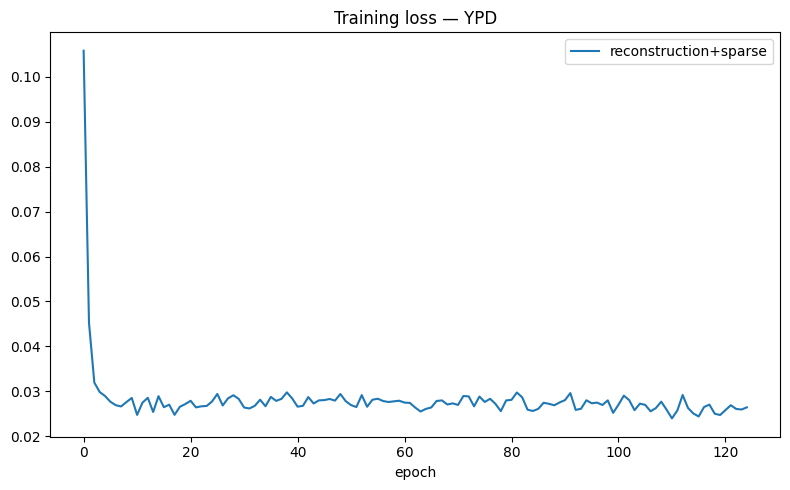

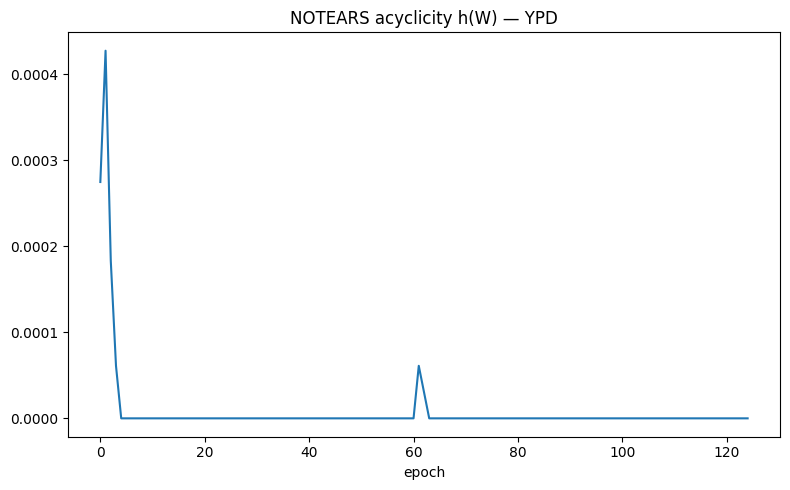


----------------------------------------------------------------------
TRAIN: YPDRapa | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0.000152588, rho=1, alpha=0.000153
outer=2/5 h(W)=6.10352e-05, rho=1, alpha=0.000214
outer=3/5 h(W)=6.10352e-05, rho=1, alpha=0.000275
outer=4/5 h(W)=0, rho=1, alpha=0.000275
outer=5/5 h(W)=0, rho=1, alpha=0.000275
Training time: 5.31 min


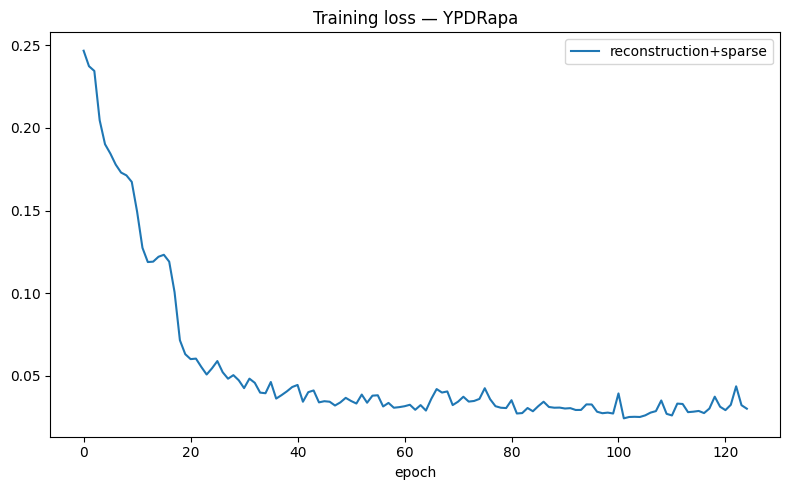

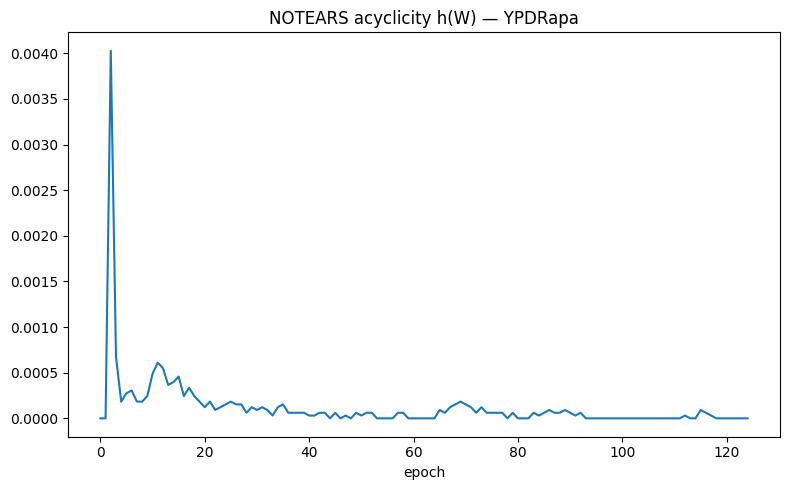


----------------------------------------------------------------------
TRAIN: YPDDiauxic | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0.00167847, rho=1, alpha=0.00168
outer=2/5 h(W)=0.000335693, rho=1, alpha=0.00201
outer=3/5 h(W)=0.000488281, rho=1, alpha=0.0025
outer=4/5 h(W)=0.000488281, rho=1, alpha=0.00299
outer=5/5 h(W)=0.000549316, rho=1, alpha=0.00354
Training time: 1.52 min


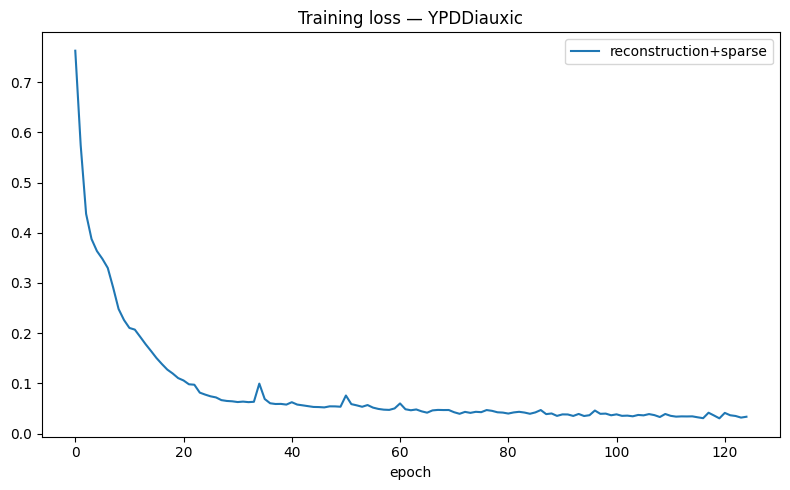

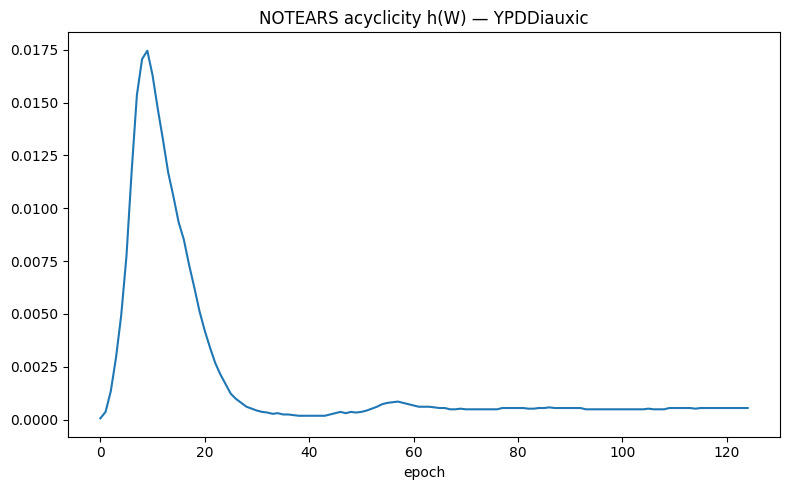


----------------------------------------------------------------------
TRAIN: CStarve | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0.00366211, rho=1, alpha=0.00366
outer=2/5 h(W)=0.000366211, rho=1, alpha=0.00403
outer=3/5 h(W)=0.00012207, rho=1, alpha=0.00415
outer=4/5 h(W)=0.00012207, rho=1, alpha=0.00427
outer=5/5 h(W)=0.00012207, rho=1, alpha=0.00439
Training time: 1.59 min


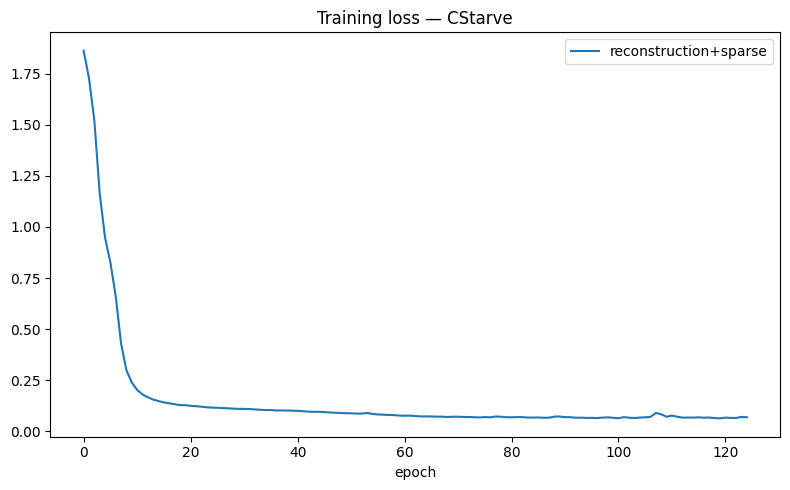

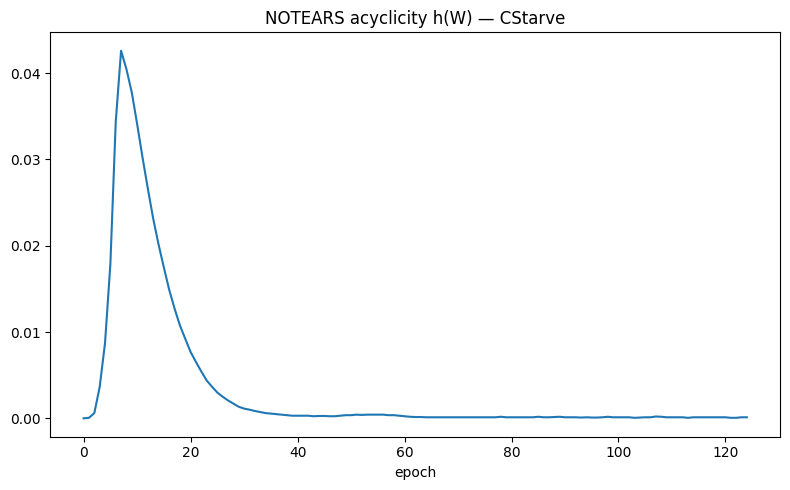

In [11]:
# ============================================================
# CELL 19 — Train all four GSE environments
# ============================================================
genes = np.array(adata_model.var_names.astype(str))
X_all = np.asarray(adata_model.X, dtype=np.float32)
PT_all = np.asarray(adata_model.obs["shared_pseudotime"], dtype=np.float32)
GENE_PT = np.asarray(gene_pt_series.loc[genes].values, dtype=np.float32)

models = {}
results = {}
timings = {}

for env in TARGET_ENVS:
    if (adata_model.obs["environment"] == env).sum() < 30:
        print(f"Skipping {env}: too few cells.")
        continue

    model, hist, elapsed = train_environment(
        env, X_all, PT_all, GENE_PT
    )
    models[env] = model
    timings[env] = elapsed

    # training plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(hist["reconstruction_plus_sparse"], label="reconstruction+sparse")
    ax.set_title(f"Training loss — {env}")
    ax.set_xlabel("epoch")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"training_loss_{env}.png", dpi=180)
    plt.show()

    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(hist["dag_h"])
    ax.set_title(f"NOTEARS acyclicity h(W) — {env}")
    ax.set_xlabel("epoch")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"dag_penalty_{env}.png", dpi=180)
    plt.show()



Computing Jacobian: YPD
Computing ablation: YPD


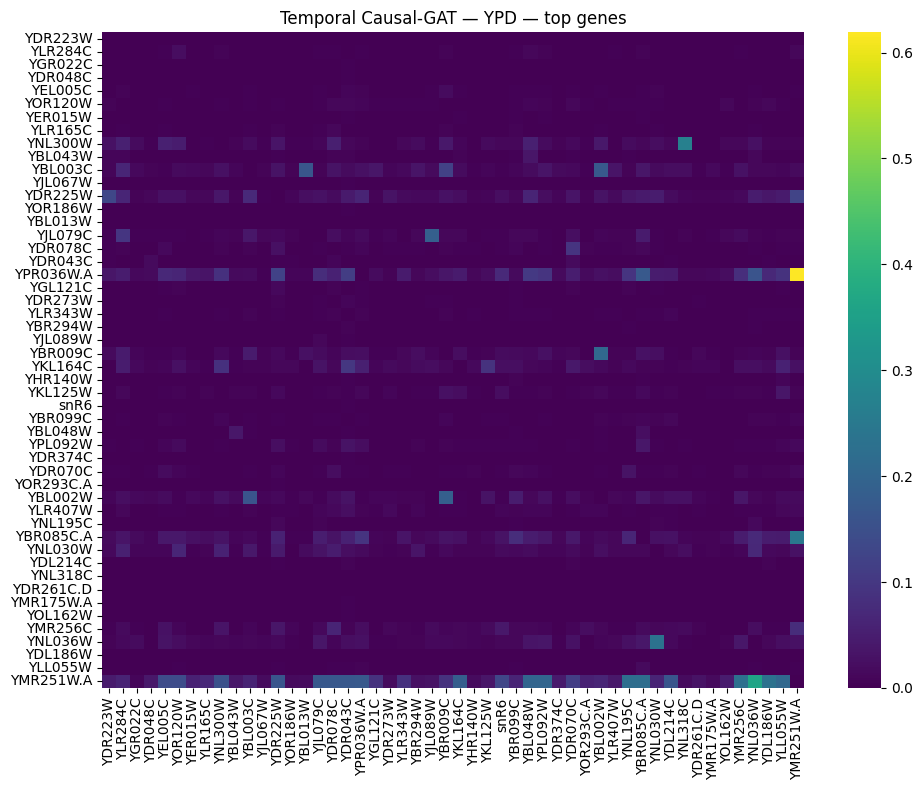

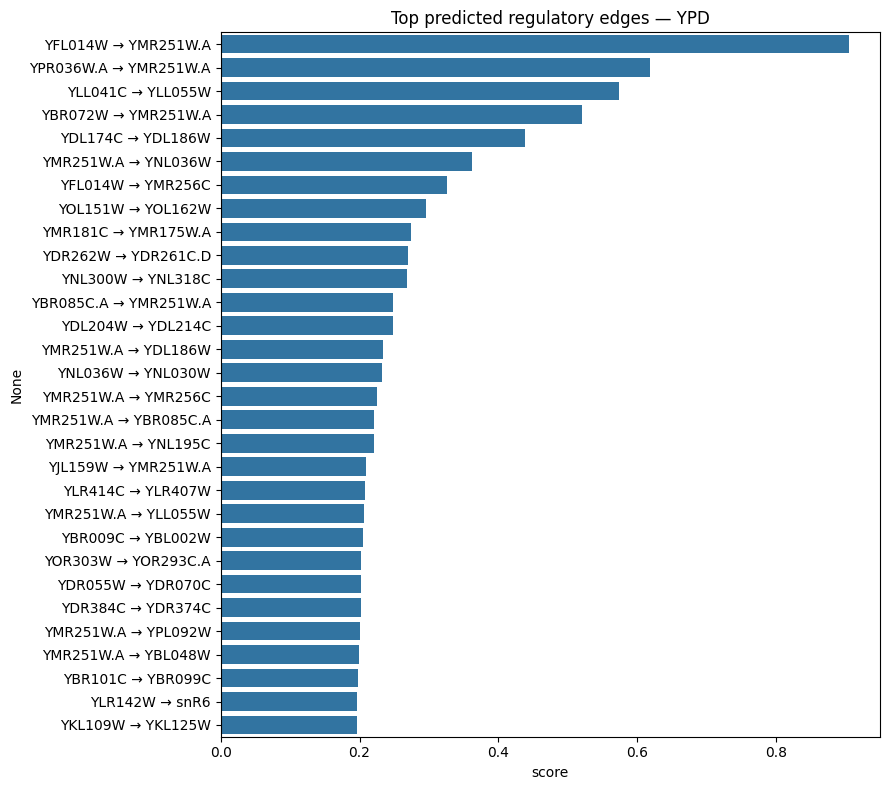


Computing Jacobian: YPDRapa
Computing ablation: YPDRapa


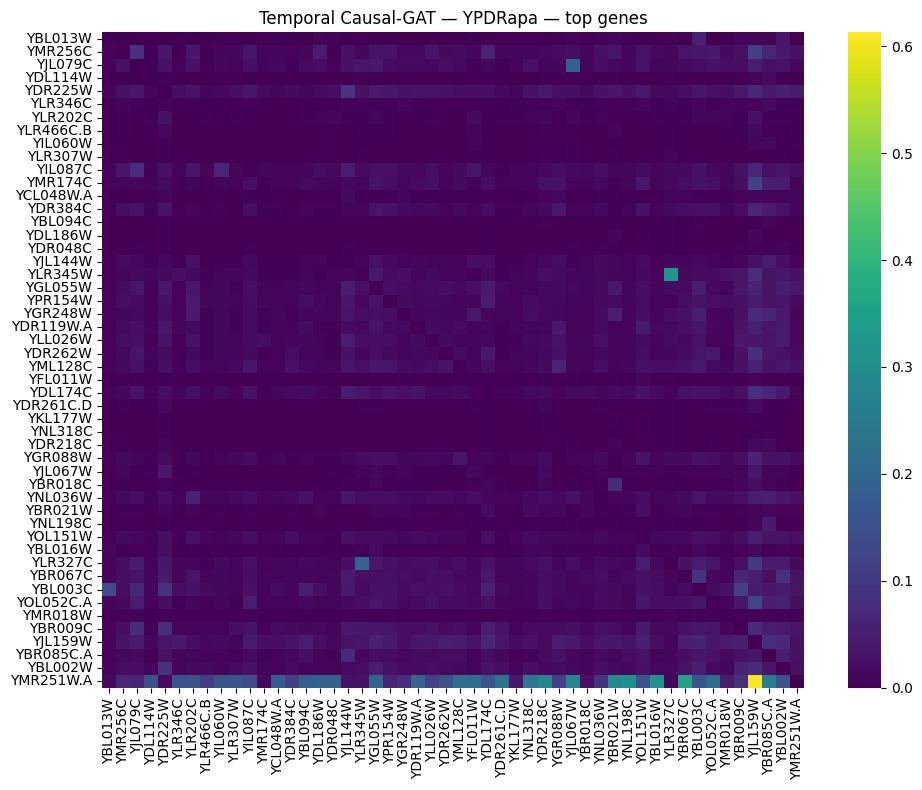

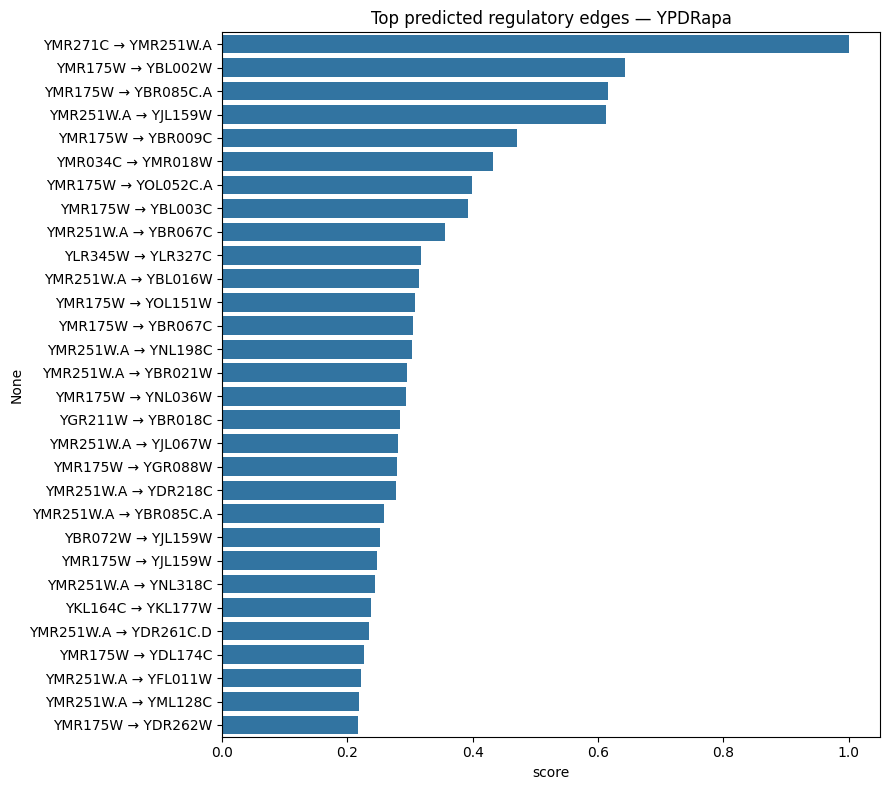


Computing Jacobian: YPDDiauxic
Computing ablation: YPDDiauxic


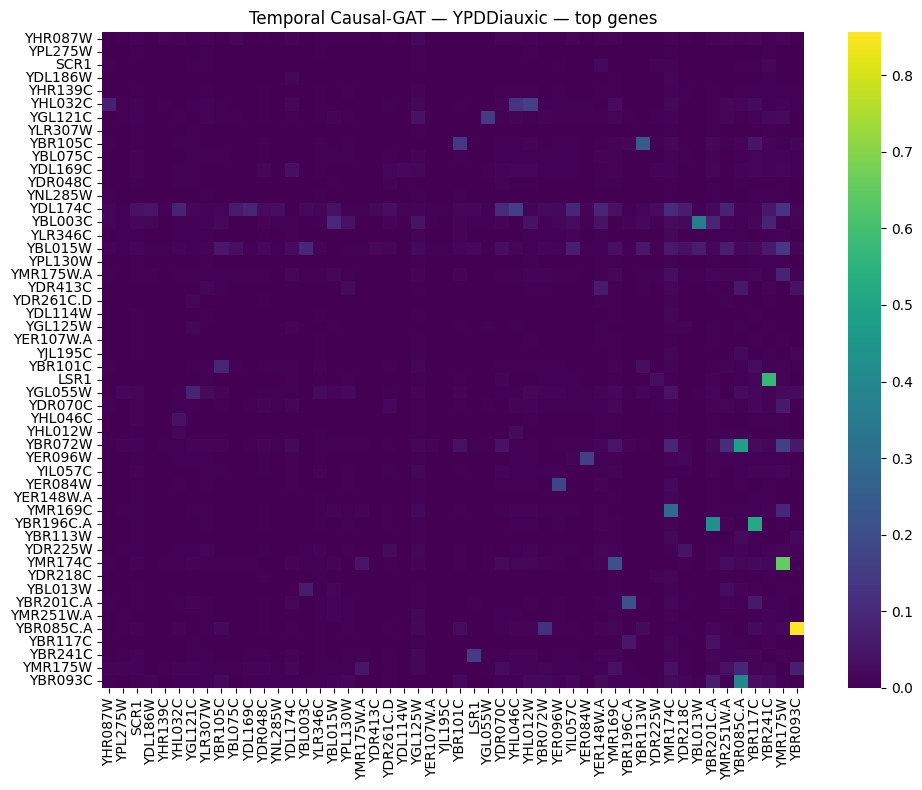

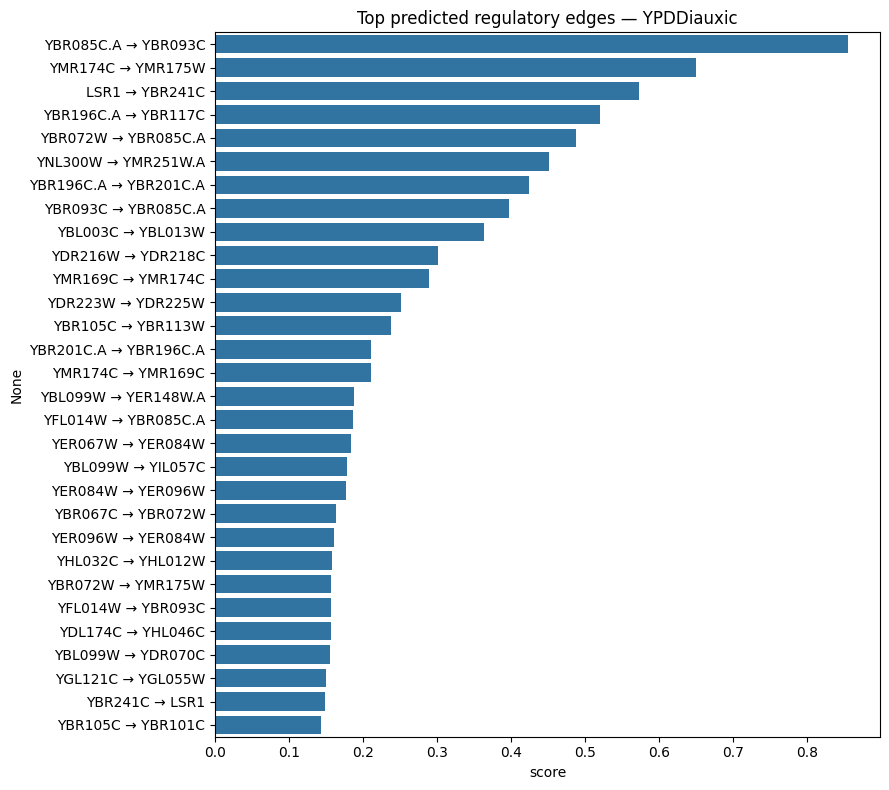


Computing Jacobian: CStarve
Computing ablation: CStarve


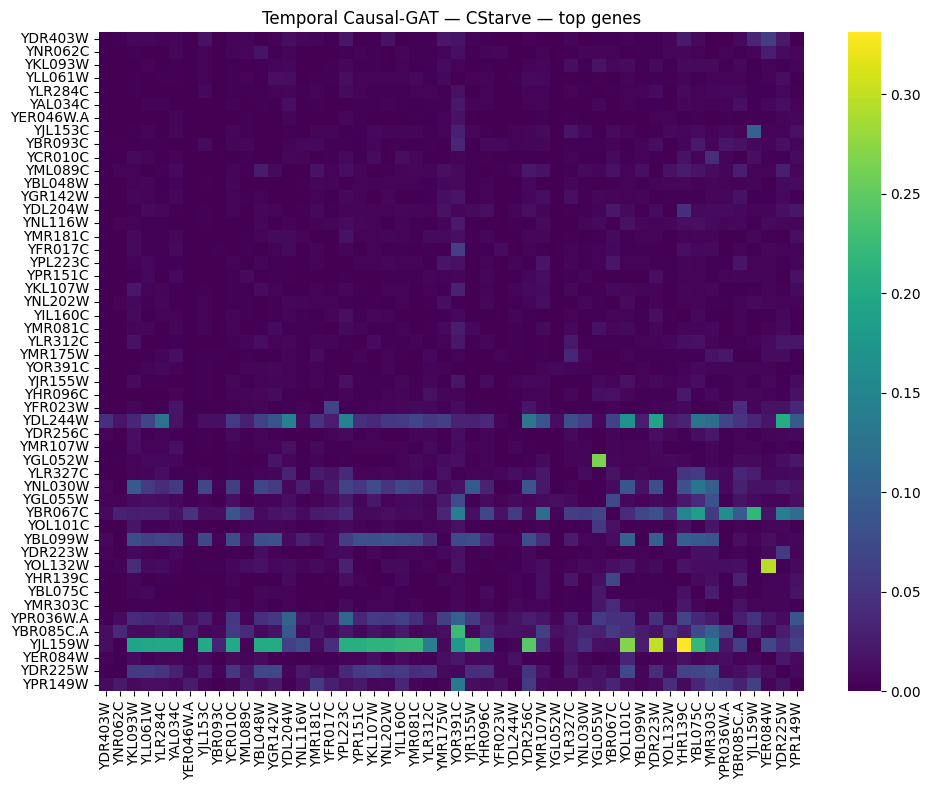

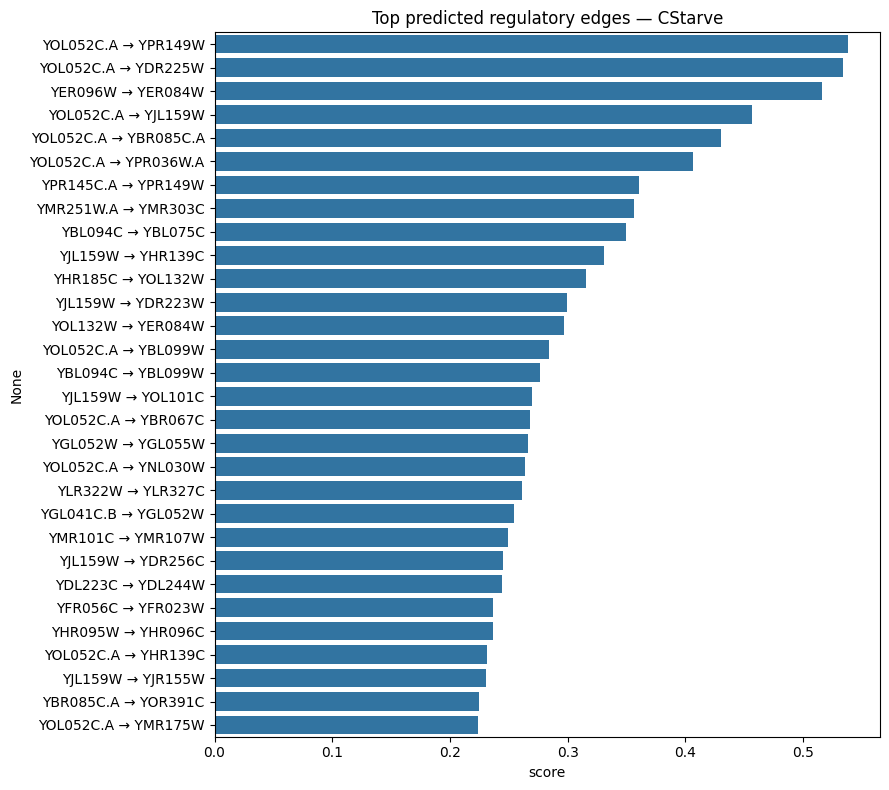

In [12]:
# ============================================================
# CELL 20 — Causal scores + baselines
# ============================================================
all_env_summary = []

for env, model in models.items():
    mask = adata_model.obs["environment"].values == env
    X_env = X_all[mask]
    pt_env = PT_all[mask]

    cond = one_hot_condition(env)
    temporal_prior = torch.tensor(GENE_PT, dtype=torch.float32, device=DEVICE)

    print("\nComputing Jacobian:", env)
    J = population_jacobian(
        model, X_env, cond, temporal_prior, chunk=INFER_CELL_CHUNK
    )

    print("Computing ablation:", env)
    A = population_ablation_scores(
        model, X_env, cond, temporal_prior, chunk=INFER_CELL_CHUNK
    )

    S = combine_causal_scores(
        J, A,
        grad_weight=GRAD_WEIGHT,
        ablation_weight=ABLATION_WEIGHT
    )

    corr_abs, corr_signed = correlation_network(X_env)

    np.save(OUT_DIR / f"jacobian_{env}.npy", J)
    np.save(OUT_DIR / f"ablation_{env}.npy", A)
    np.save(OUT_DIR / f"causal_score_{env}.npy", S)
    np.save(OUT_DIR / f"correlation_{env}.npy", corr_abs)

    # Structural W
    with torch.no_grad():
        dummy = torch.tensor(
            X_env[:min(32,len(X_env))],
            dtype=torch.float32,
            device=DEVICE
        )
        _, W, W_eff, attn = model(
            dummy,
            cond.unsqueeze(0),
            temporal_prior=temporal_prior,
            temporal_gamma=TEMPORAL_GAMMA
        )
        W_np = W.detach().cpu().numpy()
        Weff_np = W_eff.detach().cpu().numpy()

    np.save(OUT_DIR / f"W_struct_{env}.npy", W_np)
    np.save(OUT_DIR / f"W_effective_{env}.npy", Weff_np)

    # Edge tables
    matrix_to_edge_df(
        S, genes, signed_matrix=J
    ).to_csv(
        OUT_DIR / f"TemporalCausalGAT_edges_{env}.csv",
        index=False
    )

    matrix_to_edge_df(
        corr_abs, genes, signed_matrix=corr_signed
    ).to_csv(
        OUT_DIR / f"Correlation_edges_{env}.csv",
        index=False
    )

    # Heatmap: causal score
    topn = min(50, len(genes))
    top_idx = np.argsort(S.max(axis=0))[-topn:]
    H = S[np.ix_(top_idx, top_idx)]

    plt.figure(figsize=(10,8))
    sns.heatmap(
        H,
        xticklabels=genes[top_idx],
        yticklabels=genes[top_idx],
        cmap="viridis"
    )
    plt.title(f"Temporal Causal-GAT — {env} — top genes")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"GRN_heatmap_{env}.png", dpi=180)
    plt.show()

    # Top edges
    edge_df = matrix_to_edge_df(S, genes, signed_matrix=J).head(30)

    plt.figure(figsize=(9,8))
    sns.barplot(
        data=edge_df,
        x="score",
        y=edge_df["source"] + " → " + edge_df["target"]
    )
    plt.title(f"Top predicted regulatory edges — {env}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"top_edges_{env}.png", dpi=180)
    plt.show()

    # Save timing
    all_env_summary.append({
        "environment": env,
        "n_cells": int(X_env.shape[0]),
        "n_genes": int(X_env.shape[1]),
        "training_minutes": timings[env]
    })

pd.DataFrame(all_env_summary).to_csv(
    OUT_DIR / "environment_summary.csv", index=False
)

In [13]:
# ============================================================
# CHECKPOINT — Verify persistent inference outputs before evaluation
# ============================================================
# This checkpoint is intentionally placed immediately after CELL 20.
# It confirms that all four target environments have the four core
# inference matrices required by the downstream evaluation cells.
#
# Required per environment:
#   jacobian_<env>.npy
#   ablation_<env>.npy
#   causal_score_<env>.npy
#   correlation_<env>.npy
#
# Files are expected in Google Drive OUT_DIR.

print("\n" + "="*70)
print("CHECKPOINT — CELL 20 OUTPUT VERIFICATION")
print("="*70)
print("OUT_DIR:", OUT_DIR)

required_templates = [
    "jacobian_{env}.npy",
    "ablation_{env}.npy",
    "causal_score_{env}.npy",
    "correlation_{env}.npy",
]

checkpoint_rows = []
checkpoint_ok = True

for env in TARGET_ENVS:
    env_ok = True
    row = {"environment": env}

    for template in required_templates:
        fname = template.format(env=env)
        path = OUT_DIR / fname
        exists = path.exists()
        row[fname] = exists
        env_ok = env_ok and exists

        if exists:
            try:
                arr = np.load(path, mmap_mode="r")
                row[f"{fname}_shape"] = tuple(arr.shape)
                row[f"{fname}_finite"] = bool(np.isfinite(arr).all())
            except Exception as e:
                row[f"{fname}_shape"] = "LOAD_ERROR"
                row[f"{fname}_finite"] = False
                env_ok = False
                print(f"  ERROR loading {fname}: {e!r}")
        else:
            print(f"  MISSING: {fname}")

    row["environment_complete"] = env_ok
    checkpoint_ok = checkpoint_ok and env_ok
    checkpoint_rows.append(row)

checkpoint_df = pd.DataFrame(checkpoint_rows)
checkpoint_df.to_csv(
    OUT_DIR / "CELL20_output_checkpoint.csv",
    index=False
)

print("\nCheckpoint summary:")
print(checkpoint_df.to_string(index=False))

if checkpoint_ok:
    print("\n✓ All required Cell 20 outputs are present for all four environments.")
    print("✓ Downstream YEASTRACT / GENIE3 / DREAM5 cells can continue.")
else:
    raise FileNotFoundError(
        "Cell 20 output checkpoint failed. "
        "At least one required inference matrix is missing or unreadable."
    )

# Explicit memory cleanup before downstream evaluation.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



CHECKPOINT — CELL 20 OUTPUT VERIFICATION
OUT_DIR: /content/drive/MyDrive/final_grn_results

Checkpoint summary:
environment jacobian_YPD.npy jacobian_YPD.npy_shape jacobian_YPD.npy_finite ablation_YPD.npy ablation_YPD.npy_shape ablation_YPD.npy_finite causal_score_YPD.npy causal_score_YPD.npy_shape causal_score_YPD.npy_finite correlation_YPD.npy correlation_YPD.npy_shape correlation_YPD.npy_finite  environment_complete jacobian_YPDRapa.npy jacobian_YPDRapa.npy_shape jacobian_YPDRapa.npy_finite ablation_YPDRapa.npy ablation_YPDRapa.npy_shape ablation_YPDRapa.npy_finite causal_score_YPDRapa.npy causal_score_YPDRapa.npy_shape causal_score_YPDRapa.npy_finite correlation_YPDRapa.npy correlation_YPDRapa.npy_shape correlation_YPDRapa.npy_finite jacobian_YPDDiauxic.npy jacobian_YPDDiauxic.npy_shape jacobian_YPDDiauxic.npy_finite ablation_YPDDiauxic.npy ablation_YPDDiauxic.npy_shape ablation_YPDDiauxic.npy_finite causal_score_YPDDiauxic.npy causal_score_YPDDiauxic.npy_shape causal_score_YPDDia

In [14]:
# ============================================================
# RUN CONFIGURATION MANIFEST
# ============================================================
run_config = {
    "N_HVG": N_HVG,
    "INFER_CELL_CHUNK": INFER_CELL_CHUNK,
    "RUN_GENIE3": RUN_GENIE3,
    "GENIE3_MAX_CELLS": GENIE3_MAX_CELLS,
    "GENIE3_SAMPLE_SEED": GENIE3_SAMPLE_SEED,
    "GENIE3_USE_TF_RESTRICTION": GENIE3_USE_TF_RESTRICTION,
    "N_EXTRA_SEEDS": N_EXTRA_SEEDS,
    "ABLATION_ENVS": list(ABLATION_ENVS),
    "DAG_OUTER_STEPS": DAG_OUTER_STEPS,
    "EPOCHS_PER_DAG_STEP": EPOCHS_PER_DAG_STEP,
    "GRAD_WEIGHT": GRAD_WEIGHT,
    "ABLATION_WEIGHT": ABLATION_WEIGHT,
    "TARGET_ENVS": list(TARGET_ENVS),
    "OUT_DIR": str(OUT_DIR),
}
with open(OUT_DIR / "final_run_config.json", "w", encoding="utf-8") as f:
    json.dump(run_config, f, ensure_ascii=False, indent=2)

print("\nFinal run configuration:")
print(json.dumps(run_config, ensure_ascii=False, indent=2))



Final run configuration:
{
  "N_HVG": 500,
  "INFER_CELL_CHUNK": 64,
  "RUN_GENIE3": true,
  "GENIE3_MAX_CELLS": 1500,
  "GENIE3_SAMPLE_SEED": 42,
  "GENIE3_USE_TF_RESTRICTION": true,
  "N_EXTRA_SEEDS": 0,
  "ABLATION_ENVS": [],
  "DAG_OUTER_STEPS": 5,
  "EPOCHS_PER_DAG_STEP": 25,
  "GRAD_WEIGHT": 0.5,
  "ABLATION_WEIGHT": 0.5,
  "TARGET_ENVS": [
    "YPD",
    "YPDRapa",
    "YPDDiauxic",
    "CStarve"
  ],
  "OUT_DIR": "/content/drive/MyDrive/final_grn_results"
}


In [15]:
# ============================================================
# CELL 20 — YEASTRACT preparation and validation
# ============================================================

print("\n" + "="*70)
print("CELL 20 — YEASTRACT PREPARATION")
print("="*70)

# ------------------------------------------------------------
# 1. Check raw file
# ------------------------------------------------------------

if not YEASTRACT_PATH.exists():

    print(
        f"\n⚠️ YEASTRACT file not found:\n"
        f"{YEASTRACT_PATH}"
    )

    gold = None

else:

    print(
        f"\nYEASTRACT raw file found:\n"
        f"{YEASTRACT_PATH}"
    )

    # --------------------------------------------------------
    # 2. Parse + map + save
    # --------------------------------------------------------

    gold = load_gold(YEASTRACT_PATH)

    # --------------------------------------------------------
    # 3. Final validation
    # --------------------------------------------------------

    if gold is None or len(gold) == 0:

        print(
            "\n⚠️ No valid directed YEASTRACT edges were created."
        )

        gold = None

    else:

        required_columns = {"source", "target"}

        if not required_columns.issubset(gold.columns):

            raise ValueError(
                "YEASTRACT gold standard does not contain "
                "source/target columns."
            )

        # Standardize IDs
        gold["source"] = (
            gold["source"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        gold["target"] = (
            gold["target"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        # Remove invalid/self edges
        gold = gold[
            (gold["source"] != "") &
            (gold["target"] != "") &
            (gold["source"] != "NAN") &
            (gold["target"] != "NAN") &
            (gold["source"] != gold["target"])
        ].drop_duplicates().reset_index(drop=True)

        print("\n=== FINAL YEASTRACT GOLD ===")
        print("Directed gold edges:", len(gold))
        print("Unique source genes:", gold["source"].nunique())
        print("Unique target genes:", gold["target"].nunique())

        print("\nExample edges:")
        print(
            gold.head(10).to_string(index=False)
        )

        # ----------------------------------------------------
        # 4. Model-space coverage
        # ----------------------------------------------------

        model_gene_set = {
            str(g).strip().upper()
            for g in genes
        }

        gold_in_model = gold[
            gold["source"].isin(model_gene_set) &
            gold["target"].isin(model_gene_set)
        ].copy()

        print(
            "\nGold edges inside 500-gene model space:",
            len(gold_in_model),
            "/",
            len(gold)
        )

        if len(gold) > 0:

            print(
                "Gold-edge coverage:",
                f"{len(gold_in_model)/len(gold):.4f}"
            )

        # ----------------------------------------------------
        # 5. Save final validated gold
        # ----------------------------------------------------

        gold.to_csv(
            OUT_DIR / "YEASTRACT_mapped.csv",
            index=False
        )

        print(
            "\n✅ Final YEASTRACT gold standard is ready "
            "for downstream evaluation."
        )

print("\n" + "="*70)
print("CELL 20 COMPLETE")
print("="*70)


CELL 20 — YEASTRACT PREPARATION

YEASTRACT raw file found:
/content/YEASTRACT.csv

LOAD YEASTRACT GOLD STANDARD
Using existing mapped file: /content/drive/MyDrive/final_grn_results/YEASTRACT_mapped.csv
Mapped YEASTRACT edges: 12697

=== FINAL YEASTRACT GOLD ===
Directed gold edges: 12697
Unique source genes: 136
Unique target genes: 3819

Example edges:
 source  target
YNL027W YDL248W
YHR084W YDL248W
YDR207C YDL248W
YEL009C YDL248W
YMR070W YDL245C
YKL062W YDL245C
YPR065W YDL245C
YGL035C YDL245C
YMR016C YDL244W
YMR016C YDL243C

Gold edges inside 500-gene model space: 255 / 12697
Gold-edge coverage: 0.0201

✅ Final YEASTRACT gold standard is ready for downstream evaluation.

CELL 20 COMPLETE



CELL 21 — YEASTRACT EVALUATION

YEASTRACT gold edges: 12697

TF regulators inside model gene set: 16
Gold edges inside TF × target candidate space: 255
Candidate edges: 7984
Positive prevalence: 0.031939

Evaluating environment: YPD

Evaluating environment: YPDRapa

Evaluating environment: YPDDiauxic

Evaluating environment: CStarve

YEASTRACT EVALUATION RESULTS


,model,n_candidates,n_positive,AUROC,AUPRC,Precision@K,Recall@K,environment,SHD@K
0,Temporal Causal-GAT,7984,255,0.492814,0.031939,0.027451,0.027451,YPD,496
1,Correlation,7984,255,0.561468,0.042949,0.031373,0.031373,YPD,494
2,Temporal Causal-GAT,7984,255,0.464033,0.030357,0.043137,0.043137,YPDRapa,488
3,Correlation,7984,255,0.586452,0.046526,0.086275,0.086275,YPDRapa,466
4,Temporal Causal-GAT,7984,255,0.540241,0.034147,0.039216,0.039216,YPDDiauxic,490
5,Correlation,7984,255,0.574688,0.040121,0.050980,0.050980,YPDDiauxic,484
6,Temporal Causal-GAT,7984,255,0.594091,0.043121,0.050980,0.050980,CStarve,484
7,Correlation,7984,255,0.606869,0.046677,0.054902,0.054902,CStarve,482


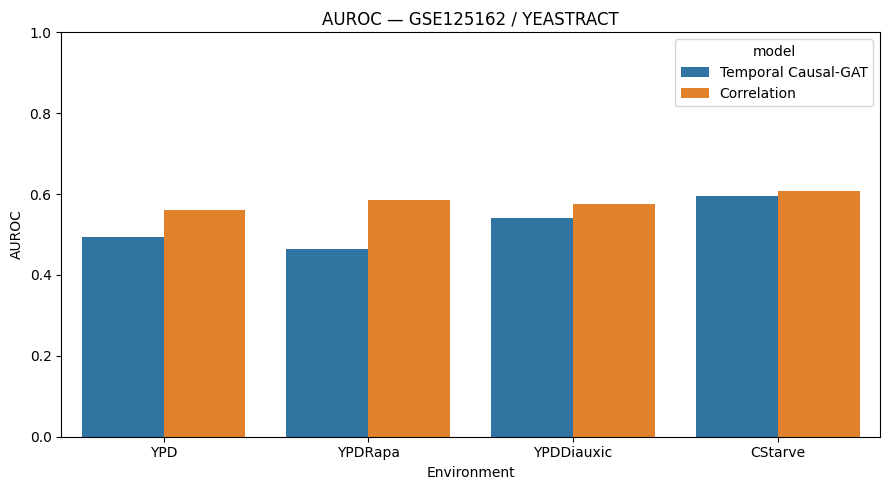

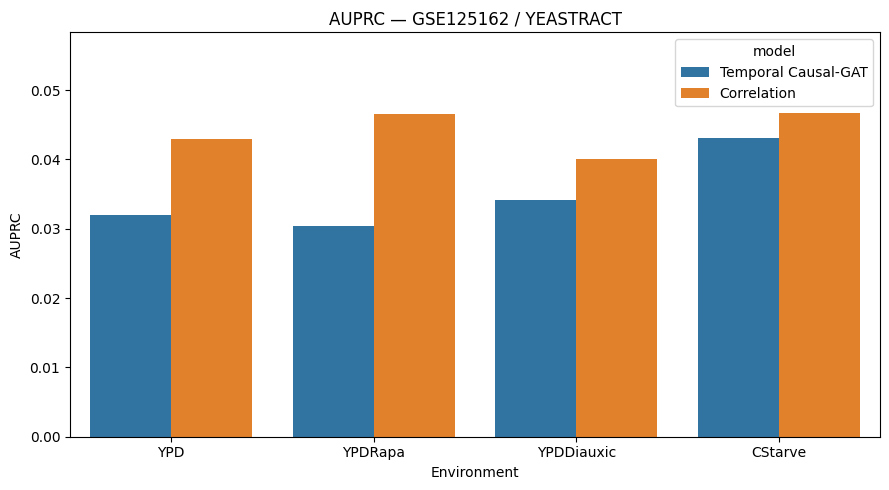

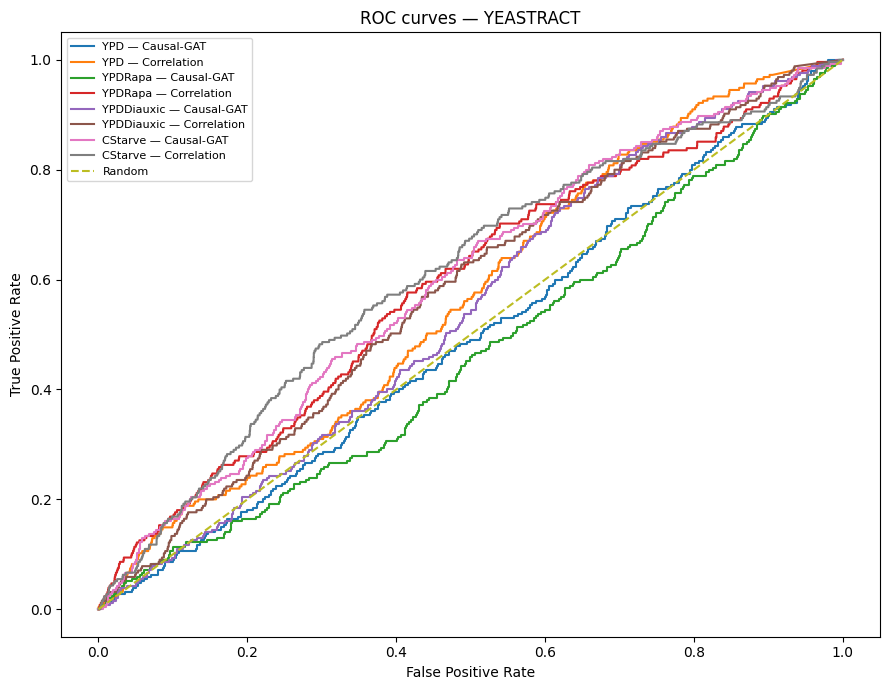

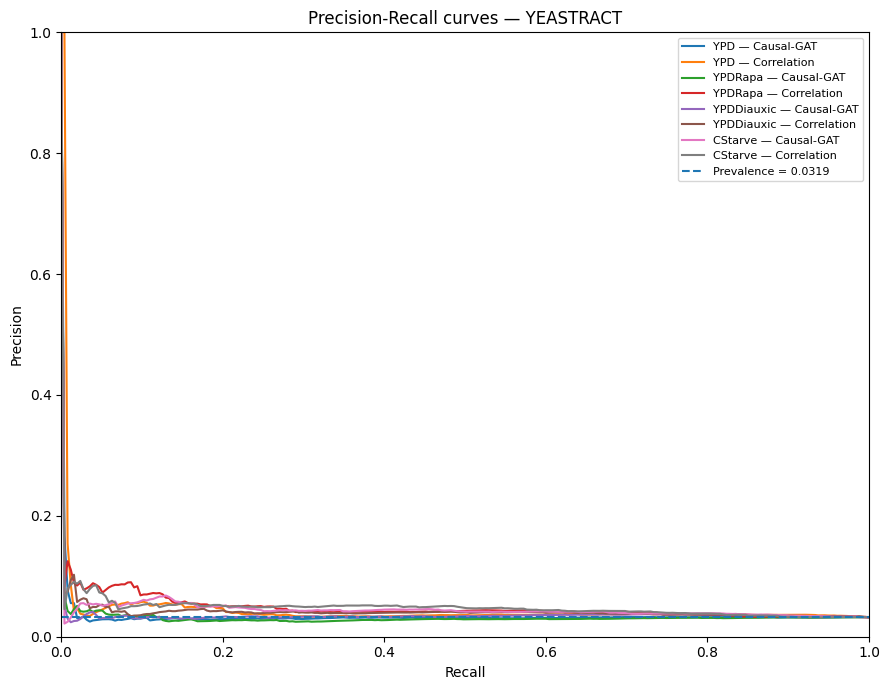


CELL 21 COMPLETE


In [16]:
# ============================================================
# CELL 21 — YEASTRACT evaluation — FINAL FIXED VERSION
# ============================================================

print("\n" + "="*70)
print("CELL 21 — YEASTRACT EVALUATION")
print("="*70)

if gold is None:

    print(
        "\n⚠️ YEASTRACT gold standard is not available."
        "\nEvaluation is skipped."
    )

else:

    print(
        "\nYEASTRACT gold edges:",
        len(gold)
    )

    eval_rows = []
    roc_data = {}
    pr_data = {}

    # --------------------------------------------------------
    # Candidate gene set
    # --------------------------------------------------------

    model_gene_set = {
        str(g).strip().upper()
        for g in genes
    }

    # --------------------------------------------------------
    # YEASTRACT TF universe
    #
    # The source universe is obtained from YEASTRACT source
    # genes and intersected with the 500-gene model space.
    #
    # This same TF × target candidate space is used for:
    #   - Temporal Causal-GAT
    #   - Correlation
    #   - GENIE3
    # --------------------------------------------------------

    eval_tfs = {
        str(x).strip().upper()
        for x in gold["source"]
        if str(x).strip().upper() in model_gene_set
    }

    if not eval_tfs:

        raise ValueError(
            "No YEASTRACT TFs were found inside the "
            "500-gene model space."
        )

    print(
        "\nTF regulators inside model gene set:",
        len(eval_tfs)
    )

    # --------------------------------------------------------
    # Gold edges inside TF × target candidate space
    # --------------------------------------------------------

    gold_in = gold[
        gold["source"].astype(str).str.upper().isin(eval_tfs)
        &
        gold["target"].astype(str).str.upper().isin(
            model_gene_set
        )
        &
        (
            gold["source"].astype(str).str.upper()
            !=
            gold["target"].astype(str).str.upper()
        )
    ].copy()

    K = len(gold_in)

    if K <= 0:

        raise ValueError(
            "No YEASTRACT gold edges are inside "
            "the TF × target candidate space."
        )

    print(
        "Gold edges inside TF × target candidate space:",
        K
    )

    n_candidates = (
        len(eval_tfs) * len(model_gene_set)
        - sum(
            1
            for tf in eval_tfs
            if tf in model_gene_set
        )
    )

    print(
        "Candidate edges:",
        n_candidates
    )

    # Positive prevalence in candidate space.
    prevalence = K / max(n_candidates, 1)

    print(
        f"Positive prevalence: {prevalence:.6f}"
    )

    # --------------------------------------------------------
    # Evaluate every trained environment
    # --------------------------------------------------------

    for env in models.keys():

        print(
            f"\nEvaluating environment: {env}"
        )

        causal_path = (
            OUT_DIR /
            f"causal_score_{env}.npy"
        )

        corr_path = (
            OUT_DIR /
            f"correlation_{env}.npy"
        )

        if not causal_path.exists():

            print(
                f"⚠️ Missing causal score for {env}; skipped."
            )
            continue

        if not corr_path.exists():

            print(
                f"⚠️ Missing correlation score for {env}; skipped."
            )
            continue

        S = np.load(
            causal_path
        )

        C = np.load(
            corr_path
        )

        expected_shape = (
            len(genes),
            len(genes)
        )

        assert S.shape == expected_shape, (
            f"Causal score shape mismatch for {env}: "
            f"{S.shape} != {expected_shape}"
        )

        assert C.shape == expected_shape, (
            f"Correlation score shape mismatch for {env}: "
            f"{C.shape} != {expected_shape}"
        )

        # ----------------------------------------------------
        # Temporal Causal-GAT
        # ----------------------------------------------------

        r1, curves1 = benchmark_score_matrix(
            S,
            genes,
            gold,
            source_restriction=eval_tfs,
            top_k=K,
            name="Temporal Causal-GAT"
        )

        r1["environment"] = env

        r1["SHD@K"] = directed_shd_at_k(
            S,
            genes,
            gold,
            K,
            source_restriction=eval_tfs
        )

        eval_rows.append(r1)

        # ----------------------------------------------------
        # Correlation
        # ----------------------------------------------------

        r2, curves2 = benchmark_score_matrix(
            C,
            genes,
            gold,
            source_restriction=eval_tfs,
            top_k=K,
            name="Correlation"
        )

        r2["environment"] = env

        r2["SHD@K"] = directed_shd_at_k(
            C,
            genes,
            gold,
            K,
            source_restriction=eval_tfs
        )

        eval_rows.append(r2)

        # ----------------------------------------------------
        # ROC / PR data
        # ----------------------------------------------------

        y1, s1 = curves1
        y2, s2 = curves2

        # ---------------- Causal-GAT ----------------

        if (
            len(np.unique(y1)) == 2
            and np.isfinite(s1).all()
        ):

            fpr, tpr, _ = roc_curve(
                y1,
                s1
            )

            roc_data[
                f"{env} — Causal-GAT"
            ] = (fpr, tpr)

            precision, recall, _ = (
                precision_recall_curve(
                    y1,
                    s1
                )
            )

            pr_data[
                f"{env} — Causal-GAT"
            ] = (
                recall,
                precision
            )

        # ---------------- Correlation ----------------

        if (
            len(np.unique(y2)) == 2
            and np.isfinite(s2).all()
        ):

            fpr, tpr, _ = roc_curve(
                y2,
                s2
            )

            roc_data[
                f"{env} — Correlation"
            ] = (fpr, tpr)

            precision, recall, _ = (
                precision_recall_curve(
                    y2,
                    s2
                )
            )

            pr_data[
                f"{env} — Correlation"
            ] = (
                recall,
                precision
            )

    # --------------------------------------------------------
    # Final evaluation table
    # --------------------------------------------------------

    eval_df = pd.DataFrame(
        eval_rows
    )

    eval_df.to_csv(
        OUT_DIR /
        "YEASTRACT_evaluation.csv",
        index=False
    )

    print("\n" + "="*70)
    print("YEASTRACT EVALUATION RESULTS")
    print("="*70)

    if len(eval_df):

        display(
            eval_df
        )

    else:

        print(
            "No evaluation results were generated."
        )

    # ========================================================
    # AUROC
    # ========================================================

    if len(eval_df):

        plt.figure(
            figsize=(9, 5)
        )

        sns.barplot(
            data=eval_df,
            x="environment",
            y="AUROC",
            hue="model"
        )

        plt.ylim(
            0,
            1
        )

        plt.ylabel("AUROC")
        plt.xlabel("Environment")

        plt.title(
            "AUROC — GSE125162 / YEASTRACT"
        )

        plt.tight_layout()

        plt.savefig(
            OUT_DIR /
            "YEASTRACT_AUROC.png",
            dpi=180
        )

        plt.show()

        # ====================================================
        # AUPRC — FIXED SCALE
        # ====================================================

        plt.figure(
            figsize=(9, 5)
        )

        sns.barplot(
            data=eval_df,
            x="environment",
            y="AUPRC",
            hue="model"
        )

        finite_auprc = (
            eval_df["AUPRC"]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if len(finite_auprc):

            max_auprc = float(
                finite_auprc.max()
            )

            # Automatically zoom into the actual AUPRC range.
            # Minimum upper bound keeps very small values visible.
            upper = max(
                0.01,
                max_auprc * 1.25
            )

            upper = min(
                upper,
                1.0
            )

        else:

            upper = 1.0

        plt.ylim(
            0,
            upper
        )

        plt.ylabel("AUPRC")
        plt.xlabel("Environment")

        plt.title(
            "AUPRC — GSE125162 / YEASTRACT"
        )

        plt.tight_layout()

        plt.savefig(
            OUT_DIR /
            "YEASTRACT_AUPRC.png",
            dpi=180
        )

        plt.show()

    # ========================================================
    # ROC curves
    # ========================================================

    if roc_data:

        plt.figure(
            figsize=(9, 7)
        )

        for label, (fpr, tpr) in roc_data.items():

            plt.plot(
                fpr,
                tpr,
                label=label
            )

        plt.plot(
            [0, 1],
            [0, 1],
            "--",
            label="Random"
        )

        plt.xlabel(
            "False Positive Rate"
        )

        plt.ylabel(
            "True Positive Rate"
        )

        plt.title(
            "ROC curves — YEASTRACT"
        )

        plt.legend(
            fontsize=8
        )

        plt.tight_layout()

        plt.savefig(
            OUT_DIR /
            "YEASTRACT_ROC_curves.png",
            dpi=180
        )

        plt.show()

    # ========================================================
    # Precision-Recall curves — FIXED VISUALIZATION
    # ========================================================

    if pr_data:

        plt.figure(
            figsize=(9, 7)
        )

        for label, (recall, precision) in pr_data.items():

            recall = np.asarray(
                recall,
                dtype=float
            )

            precision = np.asarray(
                precision,
                dtype=float
            )

            finite = (
                np.isfinite(recall)
                &
                np.isfinite(precision)
            )

            recall = recall[finite]
            precision = precision[finite]

            if len(recall) == 0:
                continue

            # ------------------------------------------------
            # Remove duplicate recall coordinates for display.
            #
            # precision_recall_curve() may contain multiple
            # precision values at the same recall, especially
            # at recall=0. Connecting those points creates the
            # artificial vertical line seen in the previous plot.
            #
            # This affects visualization only.
            # AUPRC above is calculated from the original data.
            # ------------------------------------------------

            order = np.argsort(
                recall,
                kind="mergesort"
            )

            recall = recall[order]
            precision = precision[order]

            unique_recall = []
            display_precision = []

            for r in np.unique(recall):

                p_values = precision[
                    recall == r
                ]

                unique_recall.append(r)

                # Upper envelope for display only.
                display_precision.append(
                    np.max(p_values)
                )

            unique_recall = np.asarray(
                unique_recall,
                dtype=float
            )

            display_precision = np.asarray(
                display_precision,
                dtype=float
            )

            plt.plot(
                unique_recall,
                display_precision,
                label=label
            )

        # ----------------------------------------------------
        # Random/prevalence baseline
        # ----------------------------------------------------

        plt.axhline(
            prevalence,
            linestyle="--",
            label=f"Prevalence = {prevalence:.4f}"
        )

        plt.xlabel(
            "Recall"
        )

        plt.ylabel(
            "Precision"
        )

        # Zoom to make the low-precision curves readable.
        max_pr = 0.0

        for _, (_, precision) in pr_data.items():

            precision = np.asarray(
                precision,
                dtype=float
            )

            if len(precision):

                finite_p = precision[
                    np.isfinite(precision)
                ]

                if len(finite_p):

                    max_pr = max(
                        max_pr,
                        float(finite_p.max())
                    )

        pr_upper = max(
            prevalence * 1.5,
            max_pr * 1.15,
            0.01
        )

        pr_upper = min(
            pr_upper,
            1.0
        )

        plt.ylim(
            0,
            pr_upper
        )

        plt.xlim(
            0,
            1
        )

        plt.title(
            "Precision-Recall curves — YEASTRACT"
        )

        plt.legend(
            fontsize=8
        )

        plt.tight_layout()

        plt.savefig(
            OUT_DIR /
            "YEASTRACT_PR_curves.png",
            dpi=180
        )

        plt.show()

print("\n" + "="*70)
print("CELL 21 COMPLETE")
print("="*70)

In [17]:
# ============================================================
# CHECK — Arboreto GENIE3 API
# ============================================================

import inspect
import arboreto.algo as _algo

print("Arboreto module:")
print(_algo.__file__)

print("\nGENIE3 signature:")
print(inspect.signature(_algo.genie3))

print("\nGENIE3 docstring:")
print(_algo.genie3.__doc__)

Arboreto module:
/usr/local/lib/python3.13/dist-packages/arboreto/algo.py

GENIE3 signature:
(expression_data, gene_names=None, tf_names='all', client_or_address='local', limit=None, seed=None, verbose=False)

GENIE3 docstring:

Launch arboreto with [GENIE3] profile.

:param expression_data: one of:
       * a pandas DataFrame (rows=observations, columns=genes)
       * a dense 2D numpy.ndarray
       * a sparse scipy.sparse.csc_matrix
:param gene_names: optional list of gene names (strings). Required when a (dense or sparse) matrix is passed as
                   'expression_data' instead of a DataFrame.
:param tf_names: optional list of transcription factors. If None or 'all', the list of gene_names will be used.
:param client_or_address: one of:
       * None or 'local': a new Client(LocalCluster()) will be used to perform the computation.
       * string address: a new Client(address) will be used to perform the computation.
       * a Client instance: the specified Client instance

In [18]:
# ============================================================
# CELL 22 — GENIE3 BASELINE (CLEAN NATIVE ENGINE & YEASTRACT EVAL)
# ============================================================

import gc
import time
import os
import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import RandomForestRegressor

# ============================================================
# GENIE3 Runtime Configuration
# ============================================================

GENIE3_N_WORKERS = -1  # استفاده از تمام هسته‌های CPU
GENIE3_N_ESTIMATORS = 50
GENIE3_MAX_CELLS = 1500
GENIE3_SAMPLE_SEED = 42
GENIE3_USE_TF_RESTRICTION = True

print("\n" + "="*70)
print("STEP 3 — GENIE3 BASELINE (NATIVE SCIKIT-LEARN ENGINE)")
print("="*70)

# ============================================================
# Pure Scikit-Learn Engine for GENIE3 (No Dask / No Arboreto)
# ============================================================

def run_genie3_native(X_matrix, gene_list, tf_list, n_estimators=50, seed=42, n_jobs=-1):
    """
    پیاده‌سازی مستقیم GENIE3 با Scikit-Learn برای جلوگیری از خطاهای Dask/Arboreto
    """
    n_genes = len(gene_list)
    gene2idx = {str(g).strip().upper(): i for i, g in enumerate(gene_list)}
    tf_indices = [gene2idx[str(tf).strip().upper()] for tf in tf_list if str(tf).strip().upper() in gene2idx]

    adj_matrix = np.zeros((n_genes, n_genes), dtype=np.float32)
    print(f"Running Native GENIE3 across {n_genes} genes using {len(tf_indices)} TFs...")

    for target_idx in range(n_genes):
        # Candidate predictors (TFs excluding target gene)
        predictors = [idx for idx in tf_indices if idx != target_idx]
        if not predictors:
            continue

        X_predictors = X_matrix[:, predictors]
        y_target = X_matrix[:, target_idx]

        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_features="sqrt",
            random_state=seed,
            n_jobs=n_jobs
        )
        rf.fit(X_predictors, y_target)

        importances = rf.feature_importances_
        for pred_idx, imp in zip(predictors, importances):
            adj_matrix[pred_idx, target_idx] = imp

    return adj_matrix

# ============================================================
# Pseudotime-Stratified Sampling
# ============================================================

def _select_genie3_cells(X_env, pt_env, max_cells, seed=42):
    n = len(X_env)
    if max_cells is None or n <= max_cells:
        return np.arange(n, dtype=np.int64)

    rng = np.random.default_rng(seed)
    pt = np.asarray(pt_env, dtype=np.float32)
    valid_idx = np.flatnonzero(np.isfinite(pt))

    if len(valid_idx) == 0:
        return np.sort(rng.choice(n, size=max_cells, replace=False))

    n_bins = min(10, max_cells)
    order = valid_idx[np.argsort(pt[valid_idx], kind="mergesort")]
    bins = np.array_split(order, n_bins)

    selected, remaining = [], max_cells
    for b in bins:
        if remaining <= 0: break
        take = min(len(b), max(1, int(round(max_cells * len(b) / len(order)))))
        take = min(take, remaining)
        if take > 0:
            selected.append(rng.choice(b, size=take, replace=False))
            remaining -= take

    if remaining > 0:
        already = np.concatenate(selected) if selected else np.array([], dtype=int)
        pool = np.setdiff1d(order, already)
        take = min(remaining, len(pool))
        if take > 0:
            selected.append(rng.choice(pool, size=take, replace=False))

    return np.sort(np.concatenate(selected).astype(np.int64))

# ============================================================
# Candidate TF Universe for YEASTRACT
# ============================================================

genie3_scores = {}
gene_set_upper = {str(g).strip().upper() for g in genes}
genie3_tfs = None

if GENIE3_USE_TF_RESTRICTION and 'gold' in locals() and gold is not None:
    genie3_tfs = sorted({
        str(x).strip().upper() for x in gold["source"]
        if str(x).strip().upper() in gene_set_upper
    })

if not genie3_tfs:
    genie3_tfs = [str(g).strip().upper() for g in genes]

print(f"GENIE3 TF regulators inside model gene set: {len(genie3_tfs)}")

# ============================================================
# Run GENIE3 for each Environment
# ============================================================

non_tf_idx = [i for i, g in enumerate(genes) if str(g).strip().upper() not in set(genie3_tfs)]

for env in models.keys():
    print("\n" + "-"*70)
    print(f"GENIE3 — {env}")

    mask = (adata_model.obs["environment"].values == env)
    X_env = np.asarray(X_all[mask], dtype=np.float32, order="C")
    pt_env = np.asarray(PT_all[mask], dtype=np.float32)

    sample_idx = _select_genie3_cells(X_env, pt_env, GENIE3_MAX_CELLS, seed=GENIE3_SAMPLE_SEED)
    X_g3 = np.asarray(X_env[sample_idx], dtype=np.float32, order="C")

    t0 = time.time()
    try:
        G3 = run_genie3_native(
            X_g3,
            list(genes),
            tf_list=genie3_tfs,
            n_estimators=GENIE3_N_ESTIMATORS,
            seed=GENIE3_SAMPLE_SEED,
            n_jobs=GENIE3_N_WORKERS
        )

        if non_tf_idx:
            G3[non_tf_idx, :] = 0.0

        np.fill_diagonal(G3, 0.0)
        genie3_scores[env] = G3

        np.save(OUT_DIR / f"GENIE3_{env}.npy", G3)
        print(f"GENIE3 completed for {env} in {(time.time() - t0) / 60.0:.2f} minutes")

    except Exception as e:
        print(f"GENIE3 failed for {env}: {repr(e)}")
    finally:
        del X_env, X_g3, pt_env
        gc.collect()

# ============================================================
# YEASTRACT Evaluation
# ============================================================

if 'gold' in locals() and gold is not None and len(genie3_scores) > 0:
    print("\n" + "="*70)
    print("GENIE3 — YEASTRACT EVALUATION")
    print("="*70)

    eval_tfs = set(genie3_tfs)
    gold_in = gold[
        gold["source"].astype(str).str.upper().isin(eval_tfs) &
        gold["target"].astype(str).str.upper().isin(gene_set_upper) &
        (gold["source"].astype(str).str.upper() != gold["target"].astype(str).str.upper())
    ]
    K = max(len(gold_in), 1)
    g3_rows = []

    for env, G3 in genie3_scores.items():
        if 'benchmark_score_matrix' in locals():
            res, _ = benchmark_score_matrix(
                G3, genes, gold, source_restriction=eval_tfs, top_k=K, name="GENIE3"
            )
            res["environment"] = env
            if 'directed_shd_at_k' in locals():
                res["SHD@K"] = directed_shd_at_k(G3, genes, gold, K, source_restriction=eval_tfs)
            g3_rows.append(res)

    if g3_rows:
        g3_df = pd.DataFrame(g3_rows)
        g3_df.to_csv(OUT_DIR / "GENIE3_YEASTRACT_evaluation.csv", index=False)
        from IPython.display import display
        display(g3_df)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print("\nCELL 22 COMPLETE")


STEP 3 — GENIE3 BASELINE (NATIVE SCIKIT-LEARN ENGINE)
GENIE3 TF regulators inside model gene set: 16

----------------------------------------------------------------------
GENIE3 — YPD
Running Native GENIE3 across 500 genes using 16 TFs...
GENIE3 completed for YPD in 1.01 minutes

----------------------------------------------------------------------
GENIE3 — YPDRapa
Running Native GENIE3 across 500 genes using 16 TFs...
GENIE3 completed for YPDRapa in 1.12 minutes

----------------------------------------------------------------------
GENIE3 — YPDDiauxic
Running Native GENIE3 across 500 genes using 16 TFs...
GENIE3 completed for YPDDiauxic in 1.41 minutes

----------------------------------------------------------------------
GENIE3 — CStarve
Running Native GENIE3 across 500 genes using 16 TFs...
GENIE3 completed for CStarve in 1.21 minutes

GENIE3 — YEASTRACT EVALUATION


,model,n_candidates,n_positive,AUROC,AUPRC,Precision@K,Recall@K,environment,SHD@K
0,GENIE3,7984,255,0.549956,0.033449,0.015686,0.015686,YPD,502
1,GENIE3,7984,255,0.530603,0.031657,0.015686,0.015686,YPDRapa,502
2,GENIE3,7984,255,0.533638,0.031109,0.019608,0.019608,YPDDiauxic,500
3,GENIE3,7984,255,0.569750,0.036206,0.015686,0.015686,CStarve,502



CELL 22 COMPLETE



FINAL GSE125162 comparison:
                  model  n_candidates  n_positive     AUROC     AUPRC  \
0   Temporal Causal-GAT          7984         255  0.492814  0.031939   
1           Correlation          7984         255  0.561468  0.042949   
2                GENIE3          7984         255  0.549956  0.033449   
3   Temporal Causal-GAT          7984         255  0.464033  0.030357   
4           Correlation          7984         255  0.586452  0.046526   
5                GENIE3          7984         255  0.530603  0.031657   
6   Temporal Causal-GAT          7984         255  0.540241  0.034147   
7           Correlation          7984         255  0.574688  0.040121   
8                GENIE3          7984         255  0.533638  0.031109   
9   Temporal Causal-GAT          7984         255  0.594091  0.043121   
10          Correlation          7984         255  0.606869  0.046677   
11               GENIE3          7984         255  0.569750  0.036206   

    Precision@K  Reca

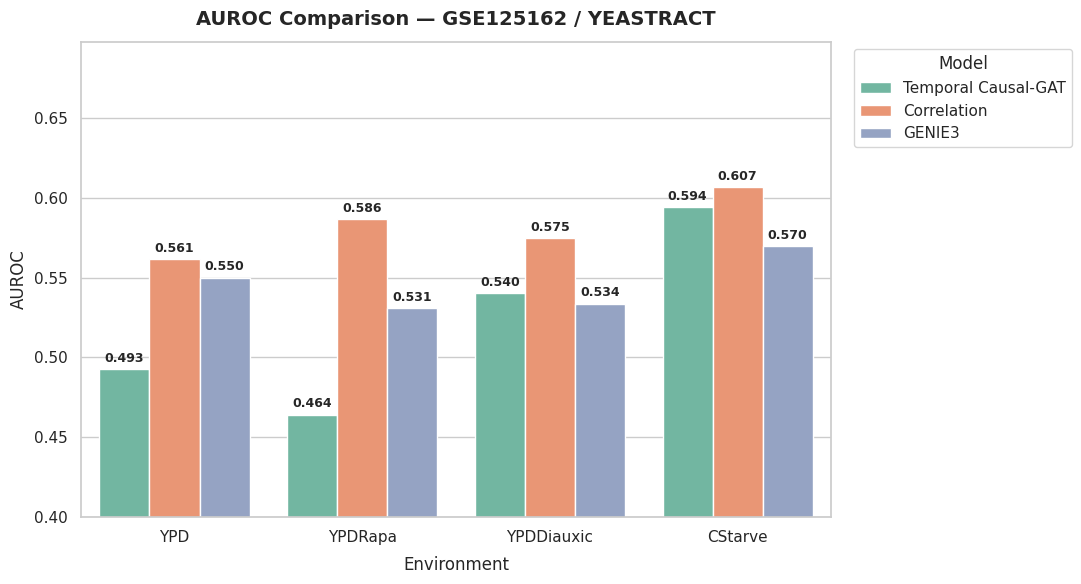

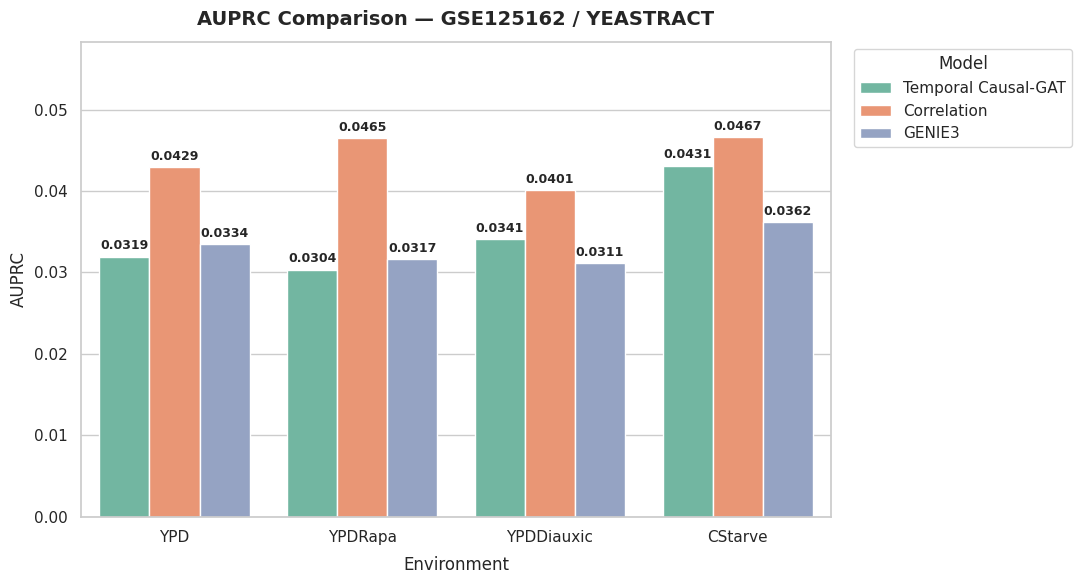


CELL 23 COMPLETE


In [19]:
# ============================================================
# CELL 23 — Final GSE model comparison & Enhanced Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

if 'gold' in locals() and gold is not None:
    comparison_rows = []

    # استخراج TFهای موجود در داده‌های واقعی YEASTRACT
    gene_set_upper = {str(g).strip().upper() for g in genes}
    eval_tfs = sorted({
        str(x).strip().upper() for x in gold["source"]
        if str(x).strip().upper() in gene_set_upper
    })

    gold_in = gold[
        gold["source"].astype(str).str.upper().isin(eval_tfs) &
        gold["target"].astype(str).str.upper().isin(gene_set_upper) &
        (gold["source"].astype(str).str.upper() != gold["target"].astype(str).str.upper())
    ]
    K = max(len(gold_in), 1)

    for env in models.keys():
        S = np.load(OUT_DIR / f"causal_score_{env}.npy")
        C = np.load(OUT_DIR / f"correlation_{env}.npy")

        models_to_eval = [
            ("Temporal Causal-GAT", S),
            ("Correlation", C)
        ]

        if 'genie3_scores' in locals() and env in genie3_scores:
            models_to_eval.append(("GENIE3", genie3_scores[env]))

        for name, M in models_to_eval:
            if 'benchmark_score_matrix' in locals():
                r, _ = benchmark_score_matrix(
                    M, genes, gold, source_restriction=eval_tfs, top_k=K, name=name
                )
                r["environment"] = env
                if 'directed_shd_at_k' in locals():
                    r["SHD@K"] = directed_shd_at_k(M, genes, gold, K, source_restriction=eval_tfs)
                comparison_rows.append(r)

    comparison = pd.DataFrame(comparison_rows)
    comparison.to_csv(OUT_DIR / "FINAL_GSE125162_MODEL_COMPARISON.csv", index=False)

    print("\nFINAL GSE125162 comparison:")
    print(comparison)

    # ============================================================
    # Enhanced Visualization with Dynamic Y-Limits & Data Labels
    # ============================================================
    sns.set_theme(style="whitegrid")

    for metric in ["AUROC", "AUPRC"]:
        if metric not in comparison.columns:
            continue

        plt.figure(figsize=(11, 6))
        ax = sns.barplot(
            data=comparison,
            x="environment",
            y=metric,
            hue="model",
            palette="Set2"
        )

        # تنظیم هوشمند محور Y جهت خوانایی مقادیر کوچک
        max_val = comparison[metric].max()
        min_val = comparison[metric].min()

        if metric == "AUROC":
            plt.ylim(0.4, min(1.0, max_val * 1.15 if max_val > 0 else 1.0))
        else:  # AUPRC
            plt.ylim(0, max_val * 1.25 if max_val > 0 else 0.05)

        # اضافه کردن برچسب مقادیر بالای هر میله (Data Labels)
        for p in ax.patches:
            height = p.get_height()
            if np.isnan(height) or height == 0:
                continue

            # فرمت‌دهی اعداد بر اساس مقدار
            label_text = f"{height:.4f}" if metric == "AUPRC" else f"{height:.3f}"

            ax.annotate(
                label_text,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                xytext=(0, 3), textcoords='offset points'
            )

        plt.title(f"{metric} Comparison — GSE125162 / YEASTRACT", fontsize=14, fontweight='bold', pad=12)
        plt.xlabel("Environment", fontsize=12, labelpad=8)
        plt.ylabel(metric, fontsize=12)
        plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
        plt.tight_layout()

        plt.savefig(OUT_DIR / f"FINAL_{metric}_comparison.png", dpi=300)
        plt.show()

print("\nCELL 23 COMPLETE")


STEP 4 — DREAM5 BENCHMARK EVALUATION

Data loaded successfully:
DREAM5 Expression Matrix: (805, 1642)
DREAM5 Gold Standard Edges: (4012, 2)
DREAM5 Total TFs: 195

DREAM5 Correlation Result:
         model  n_candidates  n_positive     AUROC     AUPRC  Precision@K  \
0  Correlation        318354        3997  0.766884  0.184004     0.271203   

   Recall@K benchmark  SHD@K  
0  0.271203    DREAM5   5826  


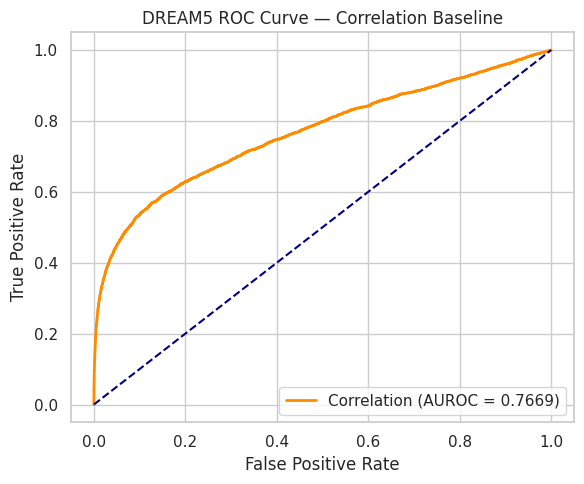

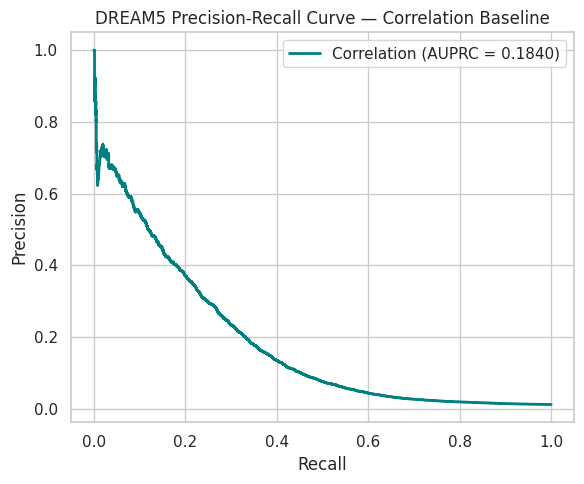


CELL 24 COMPLETE


In [20]:
# ============================================================
# CELL 24 — DREAM5 DEDICATED LOADER & BENCHMARK EVALUATION
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_curve, precision_recall_curve

print("\n" + "="*70)
print("STEP 4 — DREAM5 BENCHMARK EVALUATION")
print("="*70)

# ============================================================
# 1. File Paths
# ============================================================

DREAM5_EXPRESSION_PATH = Path("net1_expression_data.tsv")
DREAM5_GOLD_PATH = Path("DREAM5_NetworkInference_GoldStandard_Network1 - in silico.tsv")
DREAM5_TF_PATH = Path("net1_transcription_factors.tsv")

if not DREAM5_EXPRESSION_PATH.exists() and Path("DREAM5_expression.tsv").exists():
    DREAM5_EXPRESSION_PATH = Path("DREAM5_expression.tsv")

if not DREAM5_GOLD_PATH.exists():
    for alt_name in ["DREAM5_goldstandard.tsv", "net1_gold_standard.tsv"]:
        if Path(alt_name).exists():
            DREAM5_GOLD_PATH = Path(alt_name)
            break

if not DREAM5_TF_PATH.exists() and Path("DREAM5_TF_list.txt").exists():
    DREAM5_TF_PATH = Path("DREAM5_TF_list.txt")

# ============================================================
# 2. Fixed Loader Functions
# ============================================================

def load_dream5_expression(path):
    path = Path(path)
    if not path.exists():
        return None

    # Read trying to detect header properly
    try:
        df = pd.read_csv(path, sep=r"\s+", header=0, index_col=0)
    except Exception:
        df = pd.read_csv(path, sep=r"\s+")

    # If first column contains strings like 'G1', set as index
    if not np.issubdtype(df.dtypes.iloc[0], np.number):
        df = df.set_index(df.columns[0])

    # Convert all content to float, coerce non-numeric to NaN if any
    df = df.apply(pd.to_numeric, errors='coerce')

    # Orient to samples x genes (DREAM5 expression is usually Samples x Genes or Genes x Samples)
    if df.shape[0] > df.shape[1]:
        df = df.T

    df.columns = [str(c).strip() for c in df.columns]
    df.index = [str(i).strip() for i in df.index]
    return df

def load_dream5_gold(path):
    path = Path(path)
    if not path.exists():
        return None

    g = pd.read_csv(path, sep=r"\s+", header=None)
    if g.shape[1] >= 3:
        g = g[g.iloc[:, 2] == 1].iloc[:, :2]
    elif g.shape[1] == 2:
        g = g.iloc[:, :2]

    g.columns = ["source", "target"]
    g["source"] = g["source"].astype(str).str.strip()
    g["target"] = g["target"].astype(str).str.strip()
    return g.drop_duplicates()

def load_tf_list(path):
    path = Path(path)
    if not path.exists():
        return None
    vals = []
    for line in path.read_text().splitlines():
        s = line.strip()
        if s and not s.startswith("#"):
            vals.append(s.split()[0])
    return sorted(set(vals))

# ============================================================
# 3. Load Data & Run Evaluation
# ============================================================

dream_expr = load_dream5_expression(DREAM5_EXPRESSION_PATH)
dream_gold = load_dream5_gold(DREAM5_GOLD_PATH)
dream_tfs = load_tf_list(DREAM5_TF_PATH)

if dream_expr is None or dream_gold is None or dream_tfs is None:
    print("\n[ERROR] One or more DREAM5 files are missing in /content/!")
else:
    print("\nData loaded successfully:")
    print("DREAM5 Expression Matrix:", dream_expr.shape)
    print("DREAM5 Gold Standard Edges:", dream_gold.shape)
    print("DREAM5 Total TFs:", len(dream_tfs))

    dream_genes = np.array(dream_expr.columns.astype(str))
    tf_set = sorted(set(dream_tfs) & set(dream_genes))

    # Convert expression data safely to float32
    D = dream_expr.values.astype(np.float32)

    if 'correlation_network' in locals():
        corr_dream, _ = correlation_network(D)
    else:
        corr_dream = np.abs(np.corrcoef(D, rowvar=False))
        np.fill_diagonal(corr_dream, 0.0)

    dream_gold_in = dream_gold[
        dream_gold["source"].astype(str).isin(tf_set) &
        dream_gold["target"].astype(str).isin(set(dream_genes)) &
        (dream_gold["source"].astype(str) != dream_gold["target"].astype(str))
    ].copy()

    K = max(len(dream_gold_in), 1)

    if 'benchmark_score_matrix' in locals():
        r_dream, curves_dream = benchmark_score_matrix(
            corr_dream,
            dream_genes,
            dream_gold,
            source_restriction=tf_set,
            top_k=K,
            name="Correlation"
        )

        r_dream["benchmark"] = "DREAM5"
        if 'directed_shd_at_k' in locals():
            r_dream["SHD@K"] = directed_shd_at_k(corr_dream, dream_genes, dream_gold_in, K, source_restriction=tf_set)

        dream_eval = pd.DataFrame([r_dream])
        out_path = OUT_DIR / "DREAM5_correlation_evaluation.csv" if 'OUT_DIR' in locals() else Path("DREAM5_correlation_evaluation.csv")
        dream_eval.to_csv(out_path, index=False)

        print("\nDREAM5 Correlation Result:")
        print(dream_eval)

        # Plot ROC & PR Curves
        y_true, y_scores = curves_dream

        if len(y_true) > 0 and not np.isnan(r_dream.get("AUROC", np.nan)):
            plt.figure(figsize=(6, 5))
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Correlation (AUROC = {r_dream['AUROC']:.4f})")
            plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title("DREAM5 ROC Curve — Correlation Baseline")
            plt.legend(loc="lower right")
            plt.tight_layout()
            if 'OUT_DIR' in locals():
                plt.savefig(OUT_DIR / "DREAM5_ROC.png", dpi=200)
            plt.show()

            plt.figure(figsize=(6, 5))
            precision, recall, _ = precision_recall_curve(y_true, y_scores)
            plt.plot(recall, precision, color="teal", lw=2, label=f"Correlation (AUPRC = {r_dream['AUPRC']:.4f})")
            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.title("DREAM5 Precision-Recall Curve — Correlation Baseline")
            plt.legend(loc="upper right")
            plt.tight_layout()
            if 'OUT_DIR' in locals():
                plt.savefig(OUT_DIR / "DREAM5_PR.png", dpi=200)
            plt.show()

print("\nCELL 24 COMPLETE")

In [21]:
# ============================================================
# CELL 25 — Save AnnData
# ============================================================
adata_model.obs["shared_pseudotime"] = shared_pt
adata_model.write(OUT_DIR / "GSE125162_processed_model.h5ad")

# Save gene list
pd.DataFrame({"gene": genes}).to_csv(
    OUT_DIR / "final_gene_set.csv", index=False
)

# Save run configuration
config = {
    "seed": SEED,
    "target_environments": TARGET_ENVS,
    "n_hvg": N_HVG,
    "hidden": HIDDEN,
    "cond_dim": COND_DIM,
    "low_rank": LOW_RANK,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "lambda_sparse": LAMBDA_SPARSE,
    "temporal_gamma": TEMPORAL_GAMMA,
    "dag_outer_steps": DAG_OUTER_STEPS,
    "epochs_per_dag_step": EPOCHS_PER_DAG_STEP,
    "grad_weight": GRAD_WEIGHT,
    "ablation_weight": ABLATION_WEIGHT,
    "device": str(DEVICE),
}
pd.Series(config).to_csv(OUT_DIR / "run_config.csv")


In [22]:
# ============================================================
# CELL 26 — Final summary
# ============================================================
print("\n" + "="*70)
print("PIPELINE FINISHED")
print("="*70)
print("Results directory:", OUT_DIR)
print("\nMain outputs:")
print(" - GSE125162_processed_model.h5ad")
print(" - TemporalCausalGAT_edges_<ENV>.csv")
print(" - Correlation_edges_<ENV>.csv")
print(" - GENIE3_edges_<ENV>.csv (if GENIE3 succeeded)")
print(" - YEASTRACT_evaluation.csv (if YEASTRACT file supplied)")
print(" - FINAL_GSE125162_MODEL_COMPARISON.csv")
print(" - DREAM5_correlation_evaluation.csv (if DREAM5 files supplied)")
print(" - QC / UMAP / pseudotime / ROC / PR / comparison figures")
print("\nIMPORTANT FOR THESIS REPORTING:")
print("1) Report candidate gene coverage / gold-edge coverage.")
print("2) Report AUROC + AUPRC, not AUROC alone.")
print("3) Report SHD@K explicitly as a fixed-budget metric.")
print("4) GENIE3 and Correlation must use the same GSE gene set.")
print("5) DREAM5 uses TF -> target candidate space and no scRNA pseudotime.")
print("6) State that DPT is relative pseudotime and ablation is in-silico.")
print("7) Do not claim observational scRNA-seq alone proves causal identification.")



PIPELINE FINISHED
Results directory: /content/drive/MyDrive/final_grn_results

Main outputs:
 - GSE125162_processed_model.h5ad
 - TemporalCausalGAT_edges_<ENV>.csv
 - Correlation_edges_<ENV>.csv
 - GENIE3_edges_<ENV>.csv (if GENIE3 succeeded)
 - YEASTRACT_evaluation.csv (if YEASTRACT file supplied)
 - FINAL_GSE125162_MODEL_COMPARISON.csv
 - DREAM5_correlation_evaluation.csv (if DREAM5 files supplied)
 - QC / UMAP / pseudotime / ROC / PR / comparison figures

IMPORTANT FOR THESIS REPORTING:
1) Report candidate gene coverage / gold-edge coverage.
2) Report AUROC + AUPRC, not AUROC alone.
3) Report SHD@K explicitly as a fixed-budget metric.
4) GENIE3 and Correlation must use the same GSE gene set.
5) DREAM5 uses TF -> target candidate space and no scRNA pseudotime.
6) State that DPT is relative pseudotime and ablation is in-silico.
7) Do not claim observational scRNA-seq alone proves causal identification.


In [23]:
# ============================================================
# CELL 27 — Candidate / gold-edge coverage report
# ============================================================
# 🟢 (بازبینی هشتم) این سلول دقیقاً همان چیزی را که CELL 26 از قبل
# در «IMPORTANT FOR THESIS REPORTING» به‌عنوان مورد ۱ خواسته بود
# ("Report candidate gene coverage / gold-edge coverage") به‌صورت
# عددی و ذخیره‌شده در فایل تولید می‌کند؛ قبلاً این فقط یک یادآوری
# متنی بود، نه یک خروجی واقعی.
coverage_rows = []

if gold is not None:
    gold_genes = set(gold["source"].astype(str)) | set(gold["target"].astype(str))
    model_genes_set = set(genes)
    gold_in_model = gold_genes & model_genes_set
    gold_edges_covered = gold[
        gold["source"].astype(str).isin(model_genes_set) &
        gold["target"].astype(str).isin(model_genes_set)
    ]
    coverage_rows.append({
        "benchmark": "YEASTRACT",
        "n_model_genes": len(genes),
        "n_gold_genes_total": len(gold_genes),
        "n_gold_genes_in_model": len(gold_in_model),
        "gold_gene_coverage_fraction": len(gold_in_model) / max(len(gold_genes), 1),
        "n_gold_edges_total": len(gold),
        "n_gold_edges_covered": len(gold_edges_covered),
        "gold_edge_coverage_fraction": len(gold_edges_covered) / max(len(gold), 1),
    })
else:
    print("YEASTRACT gold-standard بارگذاری نشده — گزارش coverage برای آن رد می‌شود "
          "(هیچ عددی جعل نمی‌شود).")

if "dream_genes" in dir() and "dream_gold" in dir() and "tf_set" in dir():
    dream_gold_genes = set(dream_gold["source"].astype(str)) | set(dream_gold["target"].astype(str))
    dream_model_genes_set = set(dream_genes)
    dream_gold_in_model = dream_gold_genes & dream_model_genes_set
    dream_gold_edges_covered = dream_gold[
        dream_gold["source"].astype(str).isin(dream_model_genes_set) &
        dream_gold["target"].astype(str).isin(dream_model_genes_set)
    ]
    coverage_rows.append({
        "benchmark": "DREAM5",
        "n_model_genes": len(dream_genes),
        "n_gold_genes_total": len(dream_gold_genes),
        "n_gold_genes_in_model": len(dream_gold_in_model),
        "gold_gene_coverage_fraction": len(dream_gold_in_model) / max(len(dream_gold_genes), 1),
        "n_gold_edges_total": len(dream_gold),
        "n_gold_edges_covered": len(dream_gold_edges_covered),
        "gold_edge_coverage_fraction": len(dream_gold_edges_covered) / max(len(dream_gold), 1),
        "n_tfs_in_candidate_space": len(tf_set),
    })
else:
    print("فایل‌های DREAM5 بارگذاری نشده‌اند — گزارش coverage برای آن رد می‌شود "
          "(هیچ عددی جعل نمی‌شود).")

if coverage_rows:
    coverage_df = pd.DataFrame(coverage_rows)
    coverage_df.to_csv(OUT_DIR / "candidate_gold_coverage.csv", index=False)
    print("\nCandidate / gold-edge coverage:")
    print(coverage_df.to_string(index=False))
    print(
        "\nنکته برای فصل نتایج: این اعداد را همراه AUROC/AUPRC گزارش کن — "
        "یک AUROC بالا روی یک فضای کاندید با پوشش کم از گفتن (gold edges) "
        "به‌تنهایی قابل‌اتکا نیست."
    )
else:
    print("هیچ‌کدام از YEASTRACT/DREAM5 بارگذاری نشدند — گزارش coverage خالی است.")




Candidate / gold-edge coverage:
benchmark  n_model_genes  n_gold_genes_total  n_gold_genes_in_model  gold_gene_coverage_fraction  n_gold_edges_total  n_gold_edges_covered  gold_edge_coverage_fraction  n_tfs_in_candidate_space
YEASTRACT            500                3823                    364                     0.095213               12697                   255                     0.020083                       NaN
   DREAM5           1642                1565                   1564                     0.999361                4012                  3997                     0.996261                     194.0

نکته برای فصل نتایج: این اعداد را همراه AUROC/AUPRC گزارش کن — یک AUROC بالا روی یک فضای کاندید با پوشش کم از گفتن (gold edges) به‌تنهایی قابل‌اتکا نیست.


In [25]:
N_EXTRA_SEEDS = 1  # یا 2

In [29]:

# ============================================================
# CELL 28 — Multi-seed stability (mean ± SD)
# ============================================================
# 🟢 (بازبینی هشتم) اجرای اصلی (CELL 19-21) فقط با یک SEED انجام
# می‌شود. برای گزارش پایداری نتیجه نسبت به seed — که در فصل نتایج
# پایان‌نامه معمولاً به‌صورت mean ± SD گزارش می‌شود — اینجا
# N_EXTRA_SEEDS اجرای اضافی روی seedهای دیگر انجام می‌شود؛ علاوه بر
# اجرای اصلی، نه به‌جای آن. نتیجه seed اصلی (SEED) از فایل‌های
# causal_score_{env}.npy که در CELL 20 قبلاً ذخیره شده مجدداً
# محاسبه نمی‌شود (صرفه‌جویی زمان اجرا).
#
# ⚠️ هزینه محاسباتی: هر seed اضافی یعنی آموزش از صفر برای هر محیط در
# MULTISEED_ENVS. پیش‌فرض همه محیط‌های موفق را پوشش می‌دهد؛ اگر زمان
# Colab محدود است، MULTISEED_ENVS را به یک یا دو محیط نماینده محدود
# کن یا N_EXTRA_SEEDS را کاهش بده (حتی N_EXTRA_SEEDS=0 قابل قبول
# است — یعنی این بخش را رد کن و فقط به نتیجه تک‌seed اصلی اکتفا کن؛
# این باید صریحاً در فصل محدودیت‌ها ذکر شود).

# Values are defined globally in CELL 1 / configuration.
# With N_EXTRA_SEEDS=0 this section is intentionally skipped.
EXTRA_SEEDS = [SEED + 1000 + i for i in range(N_EXTRA_SEEDS)]

if gold is None:
    print("YEASTRACT gold-standard در دسترس نیست — گزارش پایداری چندseedی "
          "بدون معیار ارزیابی بی‌معنی است؛ این سلول رد می‌شود.")
elif N_EXTRA_SEEDS <= 0 or not MULTISEED_ENVS:
    print("N_EXTRA_SEEDS=0 یا هیچ محیط موفقی وجود ندارد — گزارش چندseedی "
          "رد می‌شود؛ فقط نتیجه تک‌seed اصلی معتبر است (در فصل محدودیت‌ها "
          "ذکر شود).")
else:
    multiseed_rows = []
    gold_in_ms = gold[
        gold["source"].astype(str).isin(set(genes)) &
        gold["target"].astype(str).isin(set(genes))
    ]
    K_ms = max(len(gold_in_ms), 1)

    # --- seed اصلی: از نتایج از پیش محاسبه‌شده CELL 19-21 ---
    for env in MULTISEED_ENVS:
        S_main = np.load(OUT_DIR / f"causal_score_{env}.npy")
        r_main, _ = benchmark_score_matrix(
            S_main, genes, gold, top_k=K_ms, name="Temporal Causal-GAT")
        r_main["environment"] = env
        r_main["seed"] = SEED
        r_main["SHD@K"] = directed_shd_at_k(S_main, genes, gold, K_ms)
        multiseed_rows.append(r_main)

    # --- seedهای اضافی: آموزش کامل از صفر ---
    for extra_seed in EXTRA_SEEDS:
        torch.manual_seed(extra_seed)
        np.random.seed(extra_seed)
        random.seed(extra_seed)

        for env in MULTISEED_ENVS:
            model_s, hist_s, elapsed_s = train_environment(
                env, X_all, PT_all, GENE_PT,
                verbose_prefix=f" [multiseed={extra_seed}]",
                run_tag=f"_seed{extra_seed}"
            )
            cond = one_hot_condition(env)
            temporal_prior = torch.tensor(GENE_PT, dtype=torch.float32, device=DEVICE)
            mask = adata_model.obs["environment"].values == env
            X_env = X_all[mask]

            J_s = population_jacobian(
                model_s, X_env, cond, temporal_prior, chunk=INFER_CELL_CHUNK)
            A_s = population_ablation_scores(
                model_s, X_env, cond, temporal_prior, chunk=INFER_CELL_CHUNK)
            S_s = combine_causal_scores(
                J_s, A_s, grad_weight=GRAD_WEIGHT, ablation_weight=ABLATION_WEIGHT)

            r_s, _ = benchmark_score_matrix(
                S_s, genes, gold, top_k=K_ms, name="Temporal Causal-GAT")
            r_s["environment"] = env
            r_s["seed"] = extra_seed
            r_s["SHD@K"] = directed_shd_at_k(S_s, genes, gold, K_ms)
            multiseed_rows.append(r_s)

            del model_s
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    multiseed_df = pd.DataFrame(multiseed_rows)
    multiseed_df.to_csv(OUT_DIR / "multiseed_raw_results.csv", index=False)

    summary = multiseed_df.groupby("environment").agg(
        AUROC_mean=("AUROC", "mean"), AUROC_sd=("AUROC", "std"),
        AUPRC_mean=("AUPRC", "mean"), AUPRC_sd=("AUPRC", "std"),
        SHD_at_K_mean=("SHD@K", "mean"), SHD_at_K_sd=("SHD@K", "std"),
        n_seeds=("seed", "nunique"),
    ).reset_index()
    summary.to_csv(OUT_DIR / "multiseed_summary_mean_sd.csv", index=False)
    print(f"\nMulti-seed stability ({1+N_EXTRA_SEEDS} seeds; Temporal Causal-GAT vs YEASTRACT):")
    print(summary.to_string(index=False))

    plt.figure(figsize=(9,5))
    plt.bar(summary["environment"], summary["AUROC_mean"],
            yerr=summary["AUROC_sd"].fillna(0.0), capsize=5)
    plt.ylim(0,1)
    plt.ylabel("AUROC (mean ± SD across seeds)")
    plt.title(f"Seed stability — Temporal Causal-GAT ({1+N_EXTRA_SEEDS} seeds)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "multiseed_AUROC_stability.png", dpi=180)
    plt.show()



N_EXTRA_SEEDS=0 یا هیچ محیط موفقی وجود ندارد — گزارش چندseedی رد می‌شود؛ فقط نتیجه تک‌seed اصلی معتبر است (در فصل محدودیت‌ها ذکر شود).


محیط انتخاب‌شده برای ارزیابی Ablation (نماینده شرایط پایه): ['YPD']
=== شروع فرآیند ABLATION STUDY ===

[+] در حال پردازش Ablation Study برای محیط: YPD
 -> آموزش حالت (1/2): بدون Temporal Prior...

----------------------------------------------------------------------
TRAIN: [ablation: no temporal prior] YPD | temporal_gamma=0.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0, rho=1, alpha=0
outer=2/5 h(W)=0.000244141, rho=1, alpha=0.000244
outer=3/5 h(W)=0, rho=1, alpha=0.000244
outer=4/5 h(W)=0, rho=1, alpha=0.000244
outer=5/5 h(W)=0, rho=1, alpha=0.000244
Training time: 4.94 min
 -> آموزش حالت (2/2): بدون Condition Modulation...

----------------------------------------------------------------------
TRAIN: [ablation: no condition modulation] YPD | temporal_gamma=5.0 | use_condition=False
----------------------------------------------------------------------
outer=1/5 h(W)=0, rho=1, alpha=0
outer=2/5 h(W)=0, rho=1, alpha=0


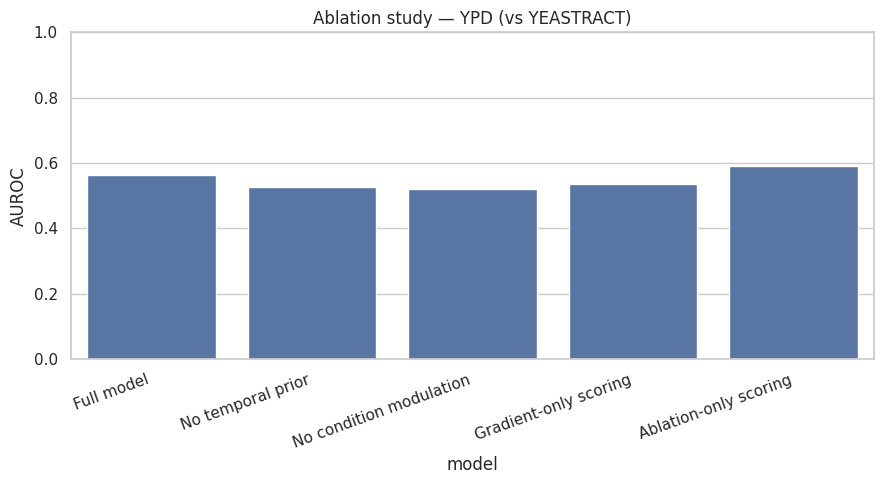


CELLS 27-29 DONE — candidate coverage, multi-seed stability, ablation study


In [36]:
# ============================================================
# CELL 29 — Ablation study (model components) [LIGHTWEIGHT RUN]
# ============================================================
import gc

# 1. تنظیم متغیرهای محیطی و مدل‌ها
trained_models = models
successful_envs = [env for env, m in trained_models.items() if m is not None]

# محدودی‌سازی به محیط اصلی YPD جهت جلوگیری از Over-Memory و Crash شدن RAM
ABLATION_ENVS = ['YPD']

print(f"محیط انتخاب‌شده برای ارزیابی Ablation (نماینده شرایط پایه): {ABLATION_ENVS}")

if gold is None:
    print("YEASTRACT gold-standard در دسترس نیست — ablation study بدون "
          "معیار ارزیابی بی‌معنی است؛ این سلول رد می‌شود.")
elif not ABLATION_ENVS:
    print("هیچ محیطی برای Ablation تعیین نشده است — ablation study رد می‌شود.")
else:
    print("=== شروع فرآیند ABLATION STUDY ===")
    ablation_rows = []
    gold_in_ab = gold[
        gold["source"].astype(str).isin(set(genes)) &
        gold["target"].astype(str).isin(set(genes))
    ]
    K_ab = max(len(gold_in_ab), 1)

    for env in ABLATION_ENVS:
        print(f"\n[+] در حال پردازش Ablation Study برای محیط: {env}")

        # پاک‌سازی پیش‌فرض حافظه قبل از شروع پردازش
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        mask = adata_model.obs["environment"].values == env
        X_env = X_all[mask]
        cond = one_hot_condition(env)
        temporal_prior_full = torch.tensor(GENE_PT, dtype=torch.float32, device=DEVICE)
        temporal_prior_zero = torch.zeros(len(genes), device=DEVICE)

        # --- (a) Full model: از نتایج از پیش محاسبه‌شده CELL 19-21 ---
        S_full = np.load(OUT_DIR / f"causal_score_{env}.npy")
        J_full = np.load(OUT_DIR / f"jacobian_{env}.npy")
        A_full = np.load(OUT_DIR / f"ablation_{env}.npy")

        r_full, _ = benchmark_score_matrix(S_full, genes, gold, top_k=K_ab, name="Full model")
        r_full["environment"] = env
        r_full["SHD@K"] = directed_shd_at_k(S_full, genes, gold, K_ab)
        ablation_rows.append(r_full)

        # --- (b) بدون temporal prior ---
        print(" -> آموزش حالت (1/2): بدون Temporal Prior...")
        model_notemp, _, _ = train_environment(
            env, X_all, PT_all, GENE_PT,
            temporal_gamma=0.0,
            verbose_prefix=" [ablation: no temporal prior]",
            run_tag="_ablation_notemp"
        )
        J_nt = population_jacobian(
            model_notemp, X_env, cond, temporal_prior_zero,
            chunk=INFER_CELL_CHUNK, temporal_gamma=0.0)
        A_nt = population_ablation_scores(
            model_notemp, X_env, cond, temporal_prior_zero,
            chunk=INFER_CELL_CHUNK, temporal_gamma=0.0)
        S_nt = combine_causal_scores(
            J_nt, A_nt, grad_weight=GRAD_WEIGHT, ablation_weight=ABLATION_WEIGHT)
        r_nt, _ = benchmark_score_matrix(S_nt, genes, gold, top_k=K_ab, name="No temporal prior")
        r_nt["environment"] = env
        r_nt["SHD@K"] = directed_shd_at_k(S_nt, genes, gold, K_ab)
        ablation_rows.append(r_nt)

        # آزادسازی اجباری RAM
        del model_notemp, J_nt, A_nt, S_nt
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # --- (c) بدون condition modulation ---
        print(" -> آموزش حالت (2/2): بدون Condition Modulation...")
        model_nocond, _, _ = train_environment(
            env, X_all, PT_all, GENE_PT,
            use_condition=False,
            verbose_prefix=" [ablation: no condition modulation]",
            run_tag="_ablation_nocond"
        )
        J_nc = population_jacobian(
            model_nocond, X_env, cond, temporal_prior_full, chunk=INFER_CELL_CHUNK)
        A_nc = population_ablation_scores(
            model_nocond, X_env, cond, temporal_prior_full, chunk=INFER_CELL_CHUNK)
        S_nc = combine_causal_scores(
            J_nc, A_nc, grad_weight=GRAD_WEIGHT, ablation_weight=ABLATION_WEIGHT)
        r_nc, _ = benchmark_score_matrix(S_nc, genes, gold, top_k=K_ab, name="No condition modulation")
        r_nc["environment"] = env
        r_nc["SHD@K"] = directed_shd_at_k(S_nc, genes, gold, K_ab)
        ablation_rows.append(r_nc)

        # آزادسازی اجباری RAM
        del model_nocond, J_nc, A_nc, S_nc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # --- (d) فقط Jacobian (بدون ablation)، بدون آموزش مجدد ---
        S_gradonly = combine_causal_scores(J_full, A_full, grad_weight=1.0, ablation_weight=0.0)
        r_go, _ = benchmark_score_matrix(S_gradonly, genes, gold, top_k=K_ab, name="Gradient-only scoring")
        r_go["environment"] = env
        r_go["SHD@K"] = directed_shd_at_k(S_gradonly, genes, gold, K_ab)
        ablation_rows.append(r_go)

        # --- (e) فقط Ablation (بدون Jacobian)، بدون آموزش مجدد ---
        S_ablonly = combine_causal_scores(J_full, A_full, grad_weight=0.0, ablation_weight=1.0)
        r_ao, _ = benchmark_score_matrix(S_ablonly, genes, gold, top_k=K_ab, name="Ablation-only scoring")
        r_ao["environment"] = env
        r_ao["SHD@K"] = directed_shd_at_k(S_ablonly, genes, gold, K_ab)
        ablation_rows.append(r_ao)

    # ساخت و ذخیره‌سازی خروجی‌ها
    ablation_df = pd.DataFrame(ablation_rows)
    ablation_df.to_csv(OUT_DIR / "ablation_study.csv", index=False)
    print("\nAblation study (vs YEASTRACT):")
    print(ablation_df[["environment","model","AUROC","AUPRC","SHD@K"]].to_string(index=False))

    # رسم نمودارها
    for env in ABLATION_ENVS:
        sub = ablation_df[ablation_df["environment"] == env]
        plt.figure(figsize=(9,5))
        sns.barplot(data=sub, x="model", y="AUROC")
        plt.ylim(0,1)
        plt.xticks(rotation=20, ha="right")
        plt.title(f"Ablation study — {env} (vs YEASTRACT)")
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"ablation_study_{env}.png", dpi=180)
        plt.show()

print("\n" + "="*70)
print("CELLS 27-29 DONE — candidate coverage, multi-seed stability, ablation study")
print("="*70)

In [32]:
# کد پیدا کردن متغیر مدل‌ها در حافظه
found_vars = []
for var_name, var_val in list(locals().items()):
    if not var_name.startswith('_'):
        if isinstance(var_val, dict) and len(var_val) > 0:
            found_vars.append((var_name, type(var_val), list(var_val.keys())[:5]))

print("دیکشنری‌های موجود در حافظه:")
for name, t, keys in found_vars:
    print(f"نام متغیر: {name} | کلیدها: {keys}")

دیکشنری‌های موجود در حافظه:
نام متغیر: ENV_MAP | کلیدها: ['YPD', 'RAPA', 'CSTARVE', 'DIAUXY', 'YPDRAPA']
نام متغیر: pt_sensitivity | کلیدها: ['YPD', 'YPDRapa', 'YPDDiauxic', 'CStarve']
نام متغیر: models | کلیدها: ['YPD', 'YPDRapa', 'YPDDiauxic', 'CStarve']
نام متغیر: timings | کلیدها: ['YPD', 'YPDRapa', 'YPDDiauxic', 'CStarve']
نام متغیر: row | کلیدها: ['environment', 'jacobian_CStarve.npy', 'jacobian_CStarve.npy_shape', 'jacobian_CStarve.npy_finite', 'ablation_CStarve.npy']
نام متغیر: run_config | کلیدها: ['N_HVG', 'INFER_CELL_CHUNK', 'RUN_GENIE3', 'GENIE3_MAX_CELLS', 'GENIE3_SAMPLE_SEED']
نام متغیر: roc_data | کلیدها: ['YPD — Causal-GAT', 'YPD — Correlation', 'YPDRapa — Causal-GAT', 'YPDRapa — Correlation', 'YPDDiauxic — Causal-GAT']
نام متغیر: pr_data | کلیدها: ['YPD — Causal-GAT', 'YPD — Correlation', 'YPDRapa — Causal-GAT', 'YPDRapa — Correlation', 'YPDDiauxic — Causal-GAT']
نام متغیر: r1 | کلیدها: ['model', 'n_candidates', 'n_positive', 'AUROC', 'AUPRC']
نام متغیر: r2 | کلیدها: [